## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO**

#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?
2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?
3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?
4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.
5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?
6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?

In our Language-MILP project, "align before fuse" means I need to first map the text and the MILP mathematical graphs into a shared space before determining if they actually match. I plan to use late fusion, which basically means computing the similarity scores of their embedding vectors. The alignment here has to be super precise, right down to the symbolic level. A rough alignment just won't cut it, because even simply swapping $\le$ for $\ge$ makes the entire math model completely wrong.

2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?

I'm thinking of running an ablation study to compare a baseline model that only uses contrastive alignment against a model that can predict specific mathematical properties (like variable types) and check logical rules. I'll test them using matched data pairs and some synthetic "hard negatives" that I'll create myself (like flipping a continuous variable into a binary one).

The biggest challenge here is definitely the "modality gap." Natural language is pretty ambiguous, but math graphs are incredibly strict. A fatal mathematical error might just be a single word in the text, and it's going to be really hard for the model to catch that amidst all the surrounding contextual noise.

3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?

The Platonic Representation Hypothesis (PRH) suggests that if we train large models on enough text and MILP data, they'll naturally learn a universal understanding of optimization. Honestly, in the context of Operations Research, I really don't think perfect mathematical alignment is just going to emerge on its own. Even extremely large models struggle to grasp strict MILP logic. They might get the general gist, but without explicit rule guidance, they'll completely miss the precise algebraic details.

4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.

One major counter-argument mentioned in the PRH paper is that different modalities inherently contain completely different amounts of information. Language relies heavily on context and implied meanings (for example, saying "shared resources" implies a capacity constraint), whereas a MILP graph is an absolutely precise topological structure. Forcing these two into the exact same space without any rules could actually destroy the mathematical rigor. Plus, PRH also touches on the fact that specialized AI, like OR solvers, often rely on specific computational shortcuts rather than trying to learn a generalized world model.

5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?

To test whether alignment will actually "emerge," I would train a few pure contrastive models with different parameter scales (without adding any explicit math rules). Then, I'd test their zero-shot ability to spot logical errors (like swapping a "min" objective to a "max"). If the PRH holds up, the accuracy in catching these mistakes should steadily go up as the model gets bigger. If the accuracy flatlines, it proves that precise mathematical alignment won't magically emerge just from scaling up.

6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

One big downside of forcing perfect alignment is that the model might overfit to specific sentence structures and lose the natural flexibility of language. If a user phrases a constraint slightly differently, the model might not recognize it anymore.

To check for this risk, I'll use "text-side perturbations" or "graph-side perturbations". I'll use an LLM to rewrite the mathematical meaning of a sentence to its exact opposite (like changing "at most" to "at least") while keeping the basic syntactic structure the same. If the model rigidly aligned the syntax instead of the actual semantics, it's going to fail to spot this fatal change.

# Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [1]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)

In [2]:
# Common PyTorch operations

# Adding 
mat_C = mat_A + mat_B.T

# Transpose
mat_A_transpose = mat_A.T

# Matrix multiplication
mat_mult = mat_A @ mat_B

# Element-wise multiplication 
mat_mult_elm = mat_A * mat_B.T

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)

# Compute mean of A
mean_A = mat_A.mean()

print("mat_C (A + B.T):\n", mat_C)
print("mat_A_transpose:\n", mat_A_transpose)
print("mat_mult (A @ B):\n", mat_mult)
print("mat_mult_elm (A * B.T):\n", mat_mult_elm)
print("ones:\n", ones)
print("mean_A:", mean_A)

mat_C (A + B.T):
 tensor([[1.5084, 0.3345],
        [1.1930, 0.6304],
        [1.0363, 1.1452]])
mat_A_transpose:
 tensor([[0.7698, 0.4641, 0.4009],
        [0.2920, 0.2779, 0.3923]])
mat_mult (A @ B):
 tensor([[0.5810, 0.6640, 0.7090],
        [0.3546, 0.4363, 0.5041],
        [0.3128, 0.4305, 0.5500]])
mat_mult_elm (A * B.T):
 tensor([[0.5686, 0.0124],
        [0.3383, 0.0980],
        [0.2547, 0.2953]])
ones:
 tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
mean_A: tensor(0.4328)


# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [3]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.3058, 0.1750, 0.1321],
        [0.4023, 0.2682, 0.1195],
        [0.5813, 0.4451, 0.0903]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [4]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
d_prod = torch.einsum('ij,ij->', a, b)

# Transpose using vector b
transpose = torch.einsum('ij->ji', b)

# Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A)
sum_column = torch.einsum('ij->j', A)

# Diagonal of A
# Diagonal of A: A is (3,2), so the main diagonal has min(3,2)=2 elements.
# Slice the square sub-matrix first, then extract diagonal with 'ii->i'
min_dim = min(A.shape)
diag = torch.einsum('ii->i', A[:min_dim, :min_dim])

# Outer Product of A and B
outer = torch.einsum('ij,kl->ijkl', A, B)

print("d_prod (dot a·b):", d_prod)
print("transpose (b.T):\n", transpose)
print("sum_element (sum all of A):", sum_element)
print("sum_column (column sums of A):", sum_column)
print("diag (diagonal of A[:2,:2]):", diag)
print("outer shape (A outer B):", outer.shape)

d_prod (dot a·b): tensor(0.8921)
transpose (b.T):
 tensor([[0.4658, 0.6782, 0.3966]])
sum_element (sum all of A): tensor(2.8711)
sum_column (column sums of A): tensor([0.9623, 1.9088])
diag (diagonal of A[:2,:2]): tensor([0.3294, 0.8527])
outer shape (A outer B): torch.Size([3, 2, 2, 3])


In [5]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i * j for i, j in zip(to_list(a), to_list(b)))
    assert float(ans) == float(expected)

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert to_list(ans) == expected

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert float(ans) == float(expected)

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert to_list(ans) == expected

def check_concat(ans, A, B):
    expected = to_list(A) + to_list(B)
    assert to_list(ans) == expected

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(len(A_list))]
    assert to_list(ans) == expected

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a), to_list(b)
    expected = [[i * j for j in b_l] for i in a_l]
    assert to_list(ans) == expected

# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

## Getting repo

In [1]:
# !git clone https://github.com/pliang279/MultiBench.git
# %cd MultiBench

In [2]:
import os
import subprocess
import sys

_cwd = os.getcwd()
BASE_DIR = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'MultiBench' else _cwd
MULTIBENCH_DIR = os.path.join(BASE_DIR, 'MultiBench')

if not os.path.isdir(MULTIBENCH_DIR):
    print("Cloning MultiBench repository...")
    subprocess.run(
        ['git', 'clone', 'https://github.com/pliang279/MultiBench.git', MULTIBENCH_DIR],
        check=True
    )
    print("Clone complete.")
else:
    print(f"MultiBench already present at: {MULTIBENCH_DIR}")

# Change into MultiBench and put it on sys.path (mirrors the original %cd MultiBench)
os.chdir(MULTIBENCH_DIR)
if MULTIBENCH_DIR not in sys.path:
    sys.path.insert(0, MULTIBENCH_DIR)
print(f"Working directory: {os.getcwd()}")

MultiBench already present at: c:\Users\PR-N\Documents\GitHub\MMAI2026\HW2\MultiBench
Working directory: c:\Users\PR-N\Documents\GitHub\MMAI2026\HW2\MultiBench


## Getting AV-MNIST dataset

In [3]:
# !mkdir data
# !pip install gdown
# !pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
# !pip install memory_profiler

In [4]:
# !gdown 1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
# !tar -xvzf avmnist.tar.gz

In [5]:
# # 1. Path to the folder you untarred
# data_dir = '/content/MultiBench/avmnist'

# from datasets.avmnist.get_data import get_dataloader
# traindata, validdata, testdata  = get_dataloader(data_dir, batch_size=256)

In [6]:
import subprocess
import sys
import os

# Install memory_profiler (all other packages are already in requirements.txt / .venv)
subprocess.run([sys.executable, '-m', 'pip', 'install', 'memory_profiler', '-q'], check=True)

os.makedirs('data', exist_ok=True)
print("Setup complete.")

Setup complete.


In [7]:
import os
import tarfile
import gdown

AVMNIST_DIR = 'avmnist'
GDRIVE_ID   = '1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp'

if not os.path.isdir(AVMNIST_DIR):
    print("Downloading AV-MNIST dataset (~1.6 GB). This may take several minutes...")
    try:
        gdown.download(
            id=GDRIVE_ID,
            output='avmnist.tar.gz',
            quiet=False,
            fuzzy=True,    # handles Google Drive confirm-token redirects
        )
        print("Extracting archive...")
        with tarfile.open('avmnist.tar.gz', 'r:gz') as tar:
            tar.extractall('.')
        os.remove('avmnist.tar.gz')
        print(f"Done. Dataset ready at ./{AVMNIST_DIR}/")
    except Exception as e:
        print(f"\n[ERROR] Download failed: {e}")
        print("Manual fallback: download the file from")
        print("  https://drive.google.com/file/d/1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp")
        print("save it as 'avmnist.tar.gz' in this folder, then run this cell again.")
else:
    print(f"AV-MNIST already present at ./{AVMNIST_DIR}/ — skipping download.")

AV-MNIST already present at ./avmnist/ — skipping download.


In [8]:
import os
import sys

# Path is relative to MultiBench/ (our current working directory)
data_dir = 'avmnist'

if not os.path.isdir(data_dir):
    raise FileNotFoundError(
        f"'{data_dir}' not found. Run the download cell above first, "
        "then re-run this cell."
    )

from datasets.avmnist.get_data import get_dataloader

# num_workers=0 is required on Windows to avoid DataLoader multiprocessing errors
traindata, validdata, testdata = get_dataloader(data_dir, batch_size=256, num_workers=0)

# Sanity-check a batch
sample = next(iter(traindata))
print(f"Image batch  : {sample[0].shape}")   # expected [256, 1, 28, 28]
print(f"Audio batch  : {sample[1].shape}")   # expected [256, 1, 112, 112]
print(f"Label batch  : {sample[2].shape}")   # expected [256]
print(f"Splits — Train: {len(traindata)} batches | Valid: {len(validdata)} | Test: {len(testdata)}")

Image batch  : torch.Size([256, 1, 28, 28])
Audio batch  : torch.Size([256, 1, 112, 112])
Label batch  : torch.Size([256])
Splits — Train: 215 batches | Valid: 20 | Test: 40


## Getting packages

In [9]:
# import torch
# import torch.nn as nn
# import sys
# import os
# import torch.optim as optim
# from tqdm import tqdm
# from unimodals.common_models import GRU, MLP, Sequential, Identity
# from training_structures.Supervised_Learning import train, test

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [11]:
import torch
print(torch.cuda.is_available())       # 应该是 True
print(torch.cuda.get_device_name(0))   # 应该显示 RTX 5060

True
NVIDIA GeForce RTX 5060 Laptop GPU


We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

## Audio

In [12]:
class AudioModel(nn.Module):
    def __init__(self, input_dim=12544, hidden_dim=64, dropout_probability=0.3):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            # Start with a stride of 2 to instantly cut data in half
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 112 -> 56
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                                      # 56 -> 28
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Flatten()  # 32 * 14 * 14 = 6272 features
        )
        self.fc = nn.Sequential(
            nn.Dropout(dropout_probability),
            nn.Linear(6272, 10)
        )

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

## Image

In [13]:
class ImageModel(nn.Module):
    def __init__(self, dropout_prob=0.3):
        super(ImageModel, self).__init__()

        # input: [batch, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Reduces size by half

        # After two poolings: 28 -> 14 -> 7
        # Final flattened size: 64 channels * 7 * 7
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Flatten all dimensions except batch
        x = torch.flatten(x, 1)
        return self.fc(x)

## Training and Testing

We use cross-entropy due to this being a classification task

In [14]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=5, lr=1e-3):
    device = torch.device("cuda")
    model.to(device)

    # Use CrossEntropyLoss for a classification task
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

    best_valid_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing follows the same logic (CrossEntropy + Index 2)
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

## Training and testing for each modality:

## Audio:

In [15]:
audio_model = AudioModel()
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1, epochs=20, lr=1e-3)

Epoch 0: Train Loss: 2.0960 | Valid Acc: 41.54%
Epoch 1: Train Loss: 1.9816 | Valid Acc: 41.50%
Epoch 2: Train Loss: 1.9501 | Valid Acc: 42.14%
Epoch 3: Train Loss: 1.9266 | Valid Acc: 41.96%
Epoch 4: Train Loss: 1.9159 | Valid Acc: 42.04%
Epoch 5: Train Loss: 1.9070 | Valid Acc: 42.16%
Epoch 6: Train Loss: 1.9023 | Valid Acc: 42.12%
Epoch 7: Train Loss: 1.8982 | Valid Acc: 42.10%
Epoch 8: Train Loss: 1.8916 | Valid Acc: 42.12%
Epoch 9: Train Loss: 1.8913 | Valid Acc: 42.04%
Epoch 10: Train Loss: 1.8897 | Valid Acc: 42.16%
Epoch 11: Train Loss: 1.8882 | Valid Acc: 42.14%
Epoch 12: Train Loss: 1.8844 | Valid Acc: 42.08%
Epoch 13: Train Loss: 1.8831 | Valid Acc: 42.10%
Epoch 14: Train Loss: 1.8813 | Valid Acc: 42.14%
Epoch 15: Train Loss: 1.8825 | Valid Acc: 42.10%
Epoch 16: Train Loss: 1.8819 | Valid Acc: 42.08%
Epoch 17: Train Loss: 1.8801 | Valid Acc: 42.08%
Epoch 18: Train Loss: 1.8799 | Valid Acc: 42.08%
Epoch 19: Train Loss: 1.8792 | Valid Acc: 42.14%

--- Final Evaluation Complete

## Image:

In [16]:
image_model = ImageModel()
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0, epochs=20, lr=1e-3)

Epoch 0: Train Loss: 1.0404 | Valid Acc: 67.24%
Epoch 1: Train Loss: 0.9485 | Valid Acc: 67.40%
Epoch 2: Train Loss: 0.9362 | Valid Acc: 68.24%
Epoch 3: Train Loss: 0.9235 | Valid Acc: 68.08%
Epoch 4: Train Loss: 0.9213 | Valid Acc: 68.38%
Epoch 5: Train Loss: 0.9163 | Valid Acc: 67.74%
Epoch 6: Train Loss: 0.9150 | Valid Acc: 68.76%
Epoch 7: Train Loss: 0.9119 | Valid Acc: 69.00%
Epoch 8: Train Loss: 0.9068 | Valid Acc: 69.30%
Epoch 9: Train Loss: 0.9074 | Valid Acc: 69.42%
Epoch 10: Train Loss: 0.9023 | Valid Acc: 68.28%
Epoch 11: Train Loss: 0.9008 | Valid Acc: 68.32%
Epoch 12: Train Loss: 0.9013 | Valid Acc: 68.88%
Epoch 13: Train Loss: 0.8977 | Valid Acc: 68.80%
Epoch 14: Train Loss: 0.8990 | Valid Acc: 69.48%
Epoch 15: Train Loss: 0.8973 | Valid Acc: 68.58%
Epoch 16: Train Loss: 0.8955 | Valid Acc: 68.50%
Epoch 17: Train Loss: 0.8947 | Valid Acc: 68.92%
Epoch 18: Train Loss: 0.8926 | Valid Acc: 69.02%
Epoch 19: Train Loss: 0.8897 | Valid Acc: 67.90%

--- Final Evaluation Complete

Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.
2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?

1.
Here are the best results I was able to get after tuning the hyperparameters:

Image Model: 65.16% test accuracy (69.48% validation)

Audio Model: 39.06% test accuracy (42.16% validation)

Hyperparameters used:
Both models were trained for 20 epochs using the Adam optimizer with a learning rate of 1e-3 and a weight decay of 1e-3. To improve generalization and prevent overfitting, I added BatchNorm2d after the convolutional layers and a Dropout(0.3) layer in the fully connected network.

2.
The image model significantly outperforms the audio model (~65% vs ~39%). (Note: The original MultiBench paper baselines show a similar gap: ~70% for image and ~42% for audio, confirming this is expected behavior).

This gap suggests that the modalities have different inherent difficulties. The MNIST images are clean, standardized, and spatially distinct, making them easy for a simple 2-layer CNN to learn. In contrast, the audio spectrograms contain a lot of noise and high intra-class variance (e.g., different speakers, accents, and speeds), which makes them fundamentally harder to classify with a basic architecture.

To get the audio model's performance closer to the image model, we could:

Use Data Augmentation: Apply techniques like SpecAugment (randomly masking frequency and time blocks) to make the model more robust to noise and variance.

Upgrade the Architecture: Use a deeper network with residual connections instead of a basic CNN to capture more complex spectro-temporal patterns.

Pre-training: Pre-train the audio model on a large audio corpus before fine-tuning it on this specific dataset.

# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [ ]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train, test

# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
            nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# TODO: Encoders - create the list of encoders, images should be first, then audio
encoders = [ImageEncoder(output_dim=64), AudioEncoder(output_dim=64)]

# TODO: Use the concat fusion as the fusion of choice
fusion = Concat()

# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.
# Concat outputs 64+64=128 dims -> head input 128, hidden 256, output 10
head = MLP(128, 256, 10)

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
# model = torch.load('avmnist_lmf.pt').cuda()
_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('avmnist_lmf.pt', weights_only=False, map_location=_device)
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...
Epoch 0 train loss: tensor(0.8893, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(0.7256, device='cuda:0') acc: 0.7308
Saving Best
Epoch 1 train loss: tensor(0.7545, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(0.7370, device='cuda:0') acc: 0.73
Epoch 2 train loss: tensor(0.7105, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: tensor(0.7506, device='cuda:0') acc: 0.7216
Epoch 3 train loss: tensor(0.6783, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(0.7304, device='cuda:0') acc: 0.7308
Epoch 4 train loss: tensor(0.6476, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(0.7315, device='cuda:0') acc: 0.729
Training Time: 26.622719287872314
Training Peak Mem: 9255.67578125
Training Params: 1077258
acc: 0.6936
Inference Time: 0.4723320007324219
Inference Params: 1077258


Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?
2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?
3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.

1.
If the loss gets stuck in a range, it usually suggests the model is trapped in a local minimum, the learning rate is too high, or it's overfitting.
Ways to fix it: Lower the learning rate, add regularization, or use early stopping.

2.
Some other methods we could use are Tensor Fusion, Low-Rank Tensor Fusion.
Yes, these would likely improve performance compared to early fusion because they explicitly model the complex interactions between the modalities, rather than just blindly concatenating raw inputs before the model has extracted any meaningful features.

3.
Early Fusion: This is when you combine the raw inputs (like image pixels and audio spectrograms) right at the beginning and pass them through a single shared model.

Benefits: It can learn low-level joint interactions between the modalities right away.

Tradeoffs: It's hard to train because different modalities have completely different shapes and data structures. It's also not modular.

Late Fusion: This is when you use separate models (encoders) for each modality to extract high-level features first, and then combine those features at the very end to make a prediction (like what we did using Concat).

Benefits: You can use specific, tailored architectures for each modality (e.g., one CNN specifically tuned for audio, another for images). It's highly modular and flexible.

Tradeoffs: It completely misses out on learning any potential cross-modal interactions at the lower levels.

# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:** *(5 points — report best validation accuracies, hyperparameters, data/model modifications, and which technique is best for your dataset)*

Write-up (5 points):

Best validation accuracies: My best validation accuracies were 71.4% for Early Fusion, 75.0% for Late Fusion, 71.4% for Tensor Fusion, and 71.4% for LMF. You can see the full results and comparison charts in section 5.10 below.

Hyperparameters: For the graph encoder, I set hidden_dim and out_dim to 128. Both text and graph embeddings are 128-dimensional. I trained the models for 50 epochs with a learning rate of 5e-4 using the AdamW optimizer and a CosineAnnealingLR scheduler.

Data/model modifications: I used the LogiOR dataset from HuggingFace. To get the mathematical graphs, I ran the Gurobi code.py files to export MPS files, and then turned those into bipartite graphs (variables and constraints). To make the model learn better, instead of using randomly mismatched text-graph pairs, I created "hard negatives". I did this by taking a correct graph and messing it up (like changing the objective from min to max, or flipping the $\le$ / $\ge$ signs) while keeping the text the same.

Best technique for this dataset: I think Late fusion is the best choice for this specific dataset. The main reason is that there is a huge "modality gap" between natural language text and strict MILP mathematical graphs. Late fusion keeps their representations separate until the final classifier, which lets each encoder focus on its own modality. Also, because our dataset is very small (only 92 problems), methods like Tensor Fusion and LMF have too many parameters and are easier to overfit. Late fusion is simpler, has fewer parameters, and converges more stably.

(Acknowledgement: The data import and modification techniques were developed by my team members Catherine Ning and Joshua Drossman. The idea of making negative pairs is Catherine's idea and is part of our group project, so basically this HW could be used for our group project later.)

## Problem 5 Implementation: Graph–Text Matching on LogiOR

###  Imports and Path Setup

In [1]:
import os, sys, json, glob, time, random, math, re
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Any, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data, Batch as PyGBatch
from sklearn.metrics import roc_auc_score, accuracy_score
from transformers import AutoTokenizer, AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
LOGIOR_DIR = DATA_DIR / 'LogiOR'
MPS_DIR = DATA_DIR / 'mps'
GRAPHS_DIR = DATA_DIR / 'graphs'
PAIR_DIR = DATA_DIR / 'pair_data'

for d in [DATA_DIR, LOGIOR_DIR, MPS_DIR, GRAPHS_DIR, PAIR_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('LOGIOR_DIR:', LOGIOR_DIR)
print('GRAPHS_DIR:', GRAPHS_DIR)
print('PAIR_DIR:', PAIR_DIR)

c:\Users\PR-N\Documents\GitHub\MMAI2026\HW2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
ROOT: c:\Users\PR-N\Documents\GitHub\MMAI2026\HW2
LOGIOR_DIR: c:\Users\PR-N\Documents\GitHub\MMAI2026\HW2\data\LogiOR
GRAPHS_DIR: c:\Users\PR-N\Documents\GitHub\MMAI2026\HW2\data\graphs
PAIR_DIR: c:\Users\PR-N\Documents\GitHub\MMAI2026\HW2\data\pair_data


### Download LogiOR Dataset

LogiOR contains 92 logistics/supply-chain optimization problems from the ORThought benchmark.
Each problem has:
- `question.txt`: natural language problem description
- `code.py`: Gurobi Python model
- `model.txt`: mathematical formulation

We download from HuggingFace (`LabMem012/LogiOR`).

In [2]:
def download_from_huggingface(out_dir: str):
    """Download LabMem012/LogiOR from HuggingFace and write prob_XXX folders."""
    try:
        from datasets import load_dataset
    except ImportError:
        print("Installing 'datasets' library...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "datasets", "-q"])
        from datasets import load_dataset

    print("Downloading LogiOR from HuggingFace (LabMem012/LogiOR)...")
    ds = load_dataset("LabMem012/LogiOR", split="train")
    print(f"  → Downloaded {len(ds)} problems")

    os.makedirs(out_dir, exist_ok=True)

    full_json_path = os.path.join(out_dir, "logior_full.json")
    ds.to_json(full_json_path)
    print(f"  → Saved full dataset to {full_json_path}")

    try:
        import pandas as pd
        meta_rows = []
        for row in ds:
            meta_rows.append({
                "prob_id": row["prob_id"],
                "problem_type": row["problem_type"],
                "problem_size": row["problem_size"],
                "solution_status": row["solution_status"],
                "ground_truth": row["ground_truth"],
                "num_vars": row["details"].get("variables_num") if isinstance(row["details"], dict) else None,
                "num_constraints": row["details"].get("constraints_num") if isinstance(row["details"], dict) else None,
            })
        df = pd.DataFrame(meta_rows)
        csv_path = os.path.join(out_dir, "metadata.csv")
        df.to_csv(csv_path, index=False)
        print(f"  → Saved metadata to {csv_path}")
    except ImportError:
        print("  (pandas not installed, skipping metadata.csv)")

    for row in ds:
        prob_id = row["prob_id"]
        prob_dir = os.path.join(out_dir, prob_id)
        os.makedirs(prob_dir, exist_ok=True)
        with open(os.path.join(prob_dir, "question.txt"), "w", encoding="utf-8") as f:
            f.write(row["description"])
        with open(os.path.join(prob_dir, "model.txt"), "w", encoding="utf-8") as f:
            f.write(row["mathematical_model"])
        with open(os.path.join(prob_dir, "code.py"), "w", encoding="utf-8") as f:
            f.write(row["gurobipy_code"])
        meta = {
            "prob_id": prob_id,
            "problem_type": row["problem_type"],
            "problem_size": row["problem_size"],
            "solution_status": row["solution_status"],
            "ground_truth": row["ground_truth"],
            "details": row["details"],
        }
        with open(os.path.join(prob_dir, "meta.json"), "w", encoding="utf-8") as f:
            json.dump(meta, f, indent=2)

    print(f"  → Created {len(ds)} problem folders in {out_dir}")
    return len(ds)

if not any(LOGIOR_DIR.glob('prob_*')):
    n = download_from_huggingface(str(LOGIOR_DIR))
    print(f'Downloaded {n} problems')
else:
    n = len(list(LOGIOR_DIR.glob('prob_*')))
    print(f'LogiOR already present: {n} problems')

example = sorted(LOGIOR_DIR.glob('prob_*'))[0]
with open(example / 'question.txt', 'r', encoding='utf-8') as f:
    print(f'\n--- {example.name}/question.txt (first 400 chars) ---')
    print(f.read()[:400])

LogiOR already present: 92 problems

--- prob_001/question.txt (first 400 chars) ---
RapidLink Logistics, a regional delivery company, needs to optimize its daily outbound operations from its main distribution hub. Today, they have 3 delivery trucks of varying capacities and 8 high-priority parcels that must be shipped. The goal is to assign each of the 8 parcels to exactly one of the three trucks to maximize the total revenue for the day.

The total revenue is composed of two par


### Export Gurobi Models to MPS Format

Each problem's `code.py` contains a Gurobi model. We execute it (without solving) to export a `.mps` file,
which is a solver-standard representation of variables, constraints, the coefficient matrix, and the objective.

In [3]:
USE_PREBUILT_GRAPHS = False

try:
    import gurobipy as gp
    print('Gurobi available, version:', gp.gurobi.version())

    _orig_optimize = gp.Model.optimize
    def _patched_optimize(self, callback=None):
        prob_id = os.environ.get('PROB_ID', 'unknown')
        out_path = str(MPS_DIR / f'{prob_id}.mps')
        self.update()
        self.write(out_path)
        raise SystemExit(0)
    gp.Model.optimize = _patched_optimize

    import runpy
    exported = 0
    for d in sorted(LOGIOR_DIR.glob('prob_*')):
        code_path = d / 'code.py'
        if not code_path.exists():
            continue
        prob_id = d.name
        os.environ['PROB_ID'] = prob_id
        try:
            runpy.run_path(str(code_path), run_name='__main__')
        except SystemExit:
            exported += 1
        except Exception as e:
            print(f'[ERR] {prob_id}: {e}')
    gp.Model.optimize = _orig_optimize
    print(f'Exported {exported} MPS files to {MPS_DIR}')

except ImportError:
    print('Gurobi not available. Using pre-built graphs from MILP-MMAI-cat_files/graphs_mps/')
    USE_PREBUILT_GRAPHS = True
    GRAPHS_DIR = ROOT / 'MILP-MMAI-cat_files' / 'graphs_mps'
    print('GRAPHS_DIR set to:', GRAPHS_DIR)

Gurobi available, version: (13, 0, 1)
Restricted license - for non-production use only - expires 2027-11-29
Set parameter NonConvex to value 2
Set parameter LazyConstraints to value 1
Set parameter LazyConstraints to value 1
Set parameter LazyConstraints to value 1
Set parameter LazyConstraints to value 1
Set parameter LazyConstraints to value 1
Set parameter LazyConstraints to value 1
Set parameter LazyConstraints to value 1
Set parameter LazyConstraints to value 1
Set parameter TimeLimit to value 3600
Set parameter LogToConsole to value 0
Set parameter NonConvex to value 2
Set parameter TimeLimit to value 60


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Enhanced Two-Echelon VRP Solver                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 60


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Weekly Delivery Routing Optimizer (Day-by-Day Approach)                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Optimizing routes for Day 1...

Set parameter LogToConsole to value 0
Set parameter TimeLimit to value 120
Set parameter NonConvex to value 2
Set parameter NonConvex to value 2
Set parameter NonConvex to value 2
Exported 92 MPS files to c:\Users\PR-N\Documents\GitHub\MMAI2026\HW2\data\mps


### Convert MPS to Bipartite Graphs

Each MPS file is converted to a bipartite graph JSON

In [4]:
def _safe_float(x, default=0.0):
    if x is None:
        return default
    try:
        x = float(x)
    except Exception:
        return default
    if x != x or abs(x) == float('inf'):
        return default
    return x


if not USE_PREBUILT_GRAPHS:
    import gurobipy as gp

    def mps_to_bipartite_graph(mps_path):
        m = gp.read(mps_path)
        m.update()
        vars_ = m.getVars()
        cons_ = m.getConstrs()
        A = m.getA()

        var_nodes = [{'id': v.VarName, 'type': 'var', 'vtype': v.VType,
                      'lb': _safe_float(v.LB), 'ub': _safe_float(v.UB),
                      'obj': float(v.Obj)} for v in vars_]
        con_nodes = [{'id': c.ConstrName, 'type': 'constr', 'sense': c.Sense,
                      'rhs': float(c.RHS)} for c in cons_]
        edges = []
        Acoo = A.tocoo()
        for r, c, val in zip(Acoo.row, Acoo.col, Acoo.data):
            edges.append({'src': cons_[r].ConstrName, 'dst': vars_[c].VarName, 'coef': float(val)})

        obj_id = '__OBJ__'
        con_nodes.append({'id': obj_id, 'type': 'obj',
                          'sense': 'min' if m.ModelSense == 1 else 'max', 'rhs': 0.0})
        for v in vars_:
            if v.Obj != 0.0:
                edges.append({'src': obj_id, 'dst': v.VarName, 'coef': float(v.Obj)})

        meta = {'num_vars': len(vars_), 'num_constrs': len(con_nodes),
                'num_edges': len(edges), 'model_sense': 'min' if m.ModelSense == 1 else 'max'}
        return {'meta': meta, 'nodes': {'vars': var_nodes, 'constrs': con_nodes}, 'edges': edges}

    converted = 0
    for mps_path in sorted(MPS_DIR.glob('prob_*.mps')):
        prob_id = mps_path.stem
        g = mps_to_bipartite_graph(str(mps_path))
        out_path = GRAPHS_DIR / f'{prob_id}_graph.json'
        with open(out_path, 'w', encoding='utf-8') as f:
            json.dump(g, f, indent=2, allow_nan=False)
        converted += 1
    print(f'Converted {converted} MPS files to bipartite graphs in {GRAPHS_DIR}')
else:
    print(f'Using {len(list(GRAPHS_DIR.glob("prob_*_graph.json")))} pre-built graphs')

Read MPS format model from file c:\Users\PR-N\Documents\GitHub\MMAI2026\HW2\data\mps\prob_001.mps
Reading time = 0.00 seconds
QuadraticKnapsackLogistics: 11 rows, 24 columns, 48 nonzeros
Read MPS format model from file c:\Users\PR-N\Documents\GitHub\MMAI2026\HW2\data\mps\prob_002.mps
Reading time = 0.00 seconds
FlightGateAssignment: 20 rows, 12 columns, 60 nonzeros
Read MPS format model from file c:\Users\PR-N\Documents\GitHub\MMAI2026\HW2\data\mps\prob_003.mps
Reading time = 0.00 seconds
BinPacking: 14 rows, 56 columns, 105 nonzeros
Read MPS format model from file c:\Users\PR-N\Documents\GitHub\MMAI2026\HW2\data\mps\prob_004.mps
Reading time = 0.00 seconds
BinPackingVariableCapacity: 13 rows, 48 columns, 90 nonzeros
Read MPS format model from file c:\Users\PR-N\Documents\GitHub\MMAI2026\HW2\data\mps\prob_005.mps
Reading time = 0.00 seconds
TransportationProblem: 8 rows, 15 columns, 30 nonzeros
Read MPS format model from file c:\Users\PR-N\Documents\GitHub\MMAI2026\HW2\data\mps\prob_00

### Building the dataset pairs

**Key insight:** Random-mismatch negatives (pairing graph_i with text_j) are too many, and also maybe easy — the model can distinguish them by superficial cues (e.g., problem scale, domain keywords) without learning true cross-modal alignment. Instead, we create **hard negatives** by taking a correct (graph, text) pair and **perturbing the graph** so it no longer matches its own text.

**Perturbation types** (applied to the graph JSON before converting to PyG):
1. **Sense inversion**: Flip constraint senses (`≤` ↔ `≥`)
2. **Variable-type swap**: Change binary → continuous, integer → binary
3. **Objective flip**: Swap `min` ↔ `max` in the objective node

For each problem, we produce:
- 1 **positive** pair: `(original_graph, text, label=1)`
- 1 **negative** pair: `(perturbed_graph, text, label=0)` — same text, corrupted graph

This gives a perfectly balanced 50/50 dataset where the model *must* learn fine-grained graph–text alignment to succeed.

In [5]:
import copy

PROB_RE = re.compile(r'prob_\d{3}')
SEED = 42
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15


# ── Graph perturbation functions ──

def perturb_sense_inversion(g):
    """Flip all constraint senses: <= <-> >=, = stays."""
    g = copy.deepcopy(g)
    flip = {'<': '>', '>': '<'}
    for c in g['nodes']['constrs']:
        if c.get('sense') in flip:
            c['sense'] = flip[c['sense']]
    return g

def perturb_vtype_swap(g):
    """Swap variable types: B->C, I->B, C->I."""
    g = copy.deepcopy(g)
    swap = {'B': 'C', 'I': 'B', 'C': 'I'}
    for v in g['nodes']['vars']:
        old = v.get('vtype', 'C')
        v['vtype'] = swap.get(old, old)
    return g

def perturb_objective_flip(g):
    """Flip min <-> max in the objective node and negate obj coefficients."""
    g = copy.deepcopy(g)
    flip_sense = {'min': 'max', 'max': 'min'}
    for c in g['nodes']['constrs']:
        if c.get('type') == 'obj' or c.get('id') == '__OBJ__':
            c['sense'] = flip_sense.get(c.get('sense', 'min'), 'max')
    for v in g['nodes']['vars']:
        v['obj'] = -v.get('obj', 0.0)
    if 'meta' in g and 'model_sense' in g['meta']:
        g['meta']['model_sense'] = flip_sense.get(g['meta']['model_sense'], 'max')
    return g

PERTURBATIONS = [
    ('sense_inv', perturb_sense_inversion),
    ('vtype_swap', perturb_vtype_swap),
    ('obj_flip', perturb_objective_flip),
]


# ── Find problems and split ──

def find_problems(graphs_dir, logior_root):
    probs = []
    for p in sorted(graphs_dir.glob('prob_*_graph.json')):
        m = PROB_RE.search(p.name)
        if not m:
            continue
        prob = m.group(0)
        txt = logior_root / prob / 'question.txt'
        if txt.exists():
            probs.append(prob)
    return probs

def split_problems(probs, seed, train_frac, val_frac):
    rng = random.Random(seed)
    probs = probs[:]
    rng.shuffle(probs)
    n = len(probs)
    n_train = int(round(train_frac * n))
    n_val = int(round(val_frac * n))
    return {'train': probs[:n_train],
            'val': probs[n_train:n_train + n_val],
            'test': probs[n_train + n_val:]}


# ── Build pairs with perturbation-based hard negatives ──

def build_perturbed_pairs(split_probs, graphs_dir, logior_root, seed):
    """
    For each problem:
      - 1 positive: (original_graph, text, label=1)
      - 1 negative: (perturbed_graph, text, label=0) using a random perturbation
    The negative uses the SAME text but a structurally corrupted graph.
    """
    rng = random.Random(seed)
    examples = []

    for prob in split_probs:
        gpath = graphs_dir / f'{prob}_graph.json'
        tpath = logior_root / prob / 'question.txt'

        with open(gpath, 'r', encoding='utf-8') as f:
            g_orig = json.load(f)
        with open(tpath, 'r', encoding='utf-8') as f:
            text = f.read()

        # Positive: original graph + its text
        examples.append({
            'graph_dict': g_orig, 'text': text,
            'prob': prob, 'label': 1, 'perturb': 'none',
        })

        # Negative: randomly pick one perturbation and apply it
        pname, pfunc = rng.choice(PERTURBATIONS)
        g_pert = pfunc(g_orig)
        examples.append({
            'graph_dict': g_pert, 'text': text,
            'prob': prob, 'label': 0, 'perturb': pname,
        })

    rng.shuffle(examples)
    return examples


all_probs = find_problems(GRAPHS_DIR, LOGIOR_DIR)
print(f'Found {len(all_probs)} problems with both graph and question.txt')

splits = split_problems(all_probs, SEED, TRAIN_FRAC, VAL_FRAC)

# Build in-memory pair lists (no JSONL needed since graphs are perturbed in memory)
split_data = {}
for split_name, split_probs in splits.items():
    seed_offset = {'train': 0, 'val': 1, 'test': 2}[split_name]
    pairs = build_perturbed_pairs(split_probs, GRAPHS_DIR, LOGIOR_DIR, SEED + seed_offset)
    split_data[split_name] = pairs
    n_pos = sum(1 for p in pairs if p['label'] == 1)
    n_neg = sum(1 for p in pairs if p['label'] == 0)
    perturb_counts = {}
    for p in pairs:
        perturb_counts[p['perturb']] = perturb_counts.get(p['perturb'], 0) + 1
    print(f'  {split_name}: {len(split_probs)} problems -> {len(pairs)} pairs '
          f'({n_pos} pos, {n_neg} neg) | perturbations: {perturb_counts}')

Found 92 problems with both graph and question.txt
  train: 64 problems -> 128 pairs (64 pos, 64 neg) | perturbations: {'obj_flip': 22, 'none': 64, 'sense_inv': 25, 'vtype_swap': 17}
  val: 14 problems -> 28 pairs (14 pos, 14 neg) | perturbations: {'vtype_swap': 5, 'none': 14, 'sense_inv': 4, 'obj_flip': 5}
  test: 14 problems -> 28 pairs (14 pos, 14 neg) | perturbations: {'sense_inv': 7, 'obj_flip': 4, 'none': 14, 'vtype_swap': 3}


### Graph–Text Pair Dataset

The dataset reads each JSONL line, loads the graph JSON, converts it to a PyG `Data` object,
and reads the question text. Returns `{graph, text, label}`.

In [6]:
@dataclass
class GraphBuildConfig:
    use_bidirectional_edges: bool = True
    add_degree_feature: bool = True
    coef_clip: float = 1e6
    coef_log1p: bool = True


def build_pyg_graph(g, cfg=None):
    if cfg is None:
        cfg = GraphBuildConfig()
    var_nodes = g['nodes']['vars']
    con_nodes = g['nodes']['constrs']
    edges = g['edges']
    n_vars, n_cons = len(var_nodes), len(con_nodes)
    n_nodes = n_vars + n_cons

    var_id_to_idx = {v['id']: i for i, v in enumerate(var_nodes)}
    con_id_to_idx = {c['id']: n_vars + i for i, c in enumerate(con_nodes)}

    x = torch.zeros((n_nodes, 6), dtype=torch.float32)
    for i, v in enumerate(var_nodes):
        lb = _safe_float(v.get('lb'), 0.0)
        ub = _safe_float(v.get('ub'), 0.0)
        obj = _safe_float(v.get('obj'), 0.0)
        vt = {'C': 0.0, 'I': 1.0, 'B': 2.0}.get(v.get('vtype', 'C'), 0.0)
        x[i] = torch.tensor([lb, ub, obj, vt, 1.0, 0.0])
    for j, c in enumerate(con_nodes):
        idx = n_vars + j
        s = {'<': -1.0, '>': 1.0, '=': 0.0}.get(c.get('sense', '='), 0.0)
        rhs = _safe_float(c.get('rhs'), 0.0)
        x[idx] = torch.tensor([s, rhs, 0.0, 0.0, 0.0, 1.0])

    src_list, dst_list, ea_list = [], [], []
    for e in edges:
        coef = _safe_float(e.get('coef'), 0.0)
        if e['src'] in con_id_to_idx and e['dst'] in var_id_to_idx:
            u, v = con_id_to_idx[e['src']], var_id_to_idx[e['dst']]
        else:
            continue
        src_list.append(u); dst_list.append(v); ea_list.append(coef)
        if cfg.use_bidirectional_edges:
            src_list.append(v); dst_list.append(u); ea_list.append(coef)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr = torch.tensor(ea_list, dtype=torch.float32).view(-1, 1)
    if cfg.coef_log1p:
        edge_attr = torch.sign(edge_attr) * torch.log1p(torch.clamp(edge_attr.abs(), max=cfg.coef_clip))

    if cfg.add_degree_feature:
        deg = torch.zeros((n_nodes,), dtype=torch.float32)
        for u in src_list:
            deg[u] += 1.0
        x = torch.cat([x, torch.log1p(deg).view(-1, 1)], dim=1)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


class PerturbedPairDataset(Dataset):
    """In-memory dataset of (graph_dict, text, label) pairs with perturbed negatives."""
    def __init__(self, pairs, graph_cfg=None, max_text_chars=8000):
        self.pairs = pairs
        self.graph_cfg = graph_cfg or GraphBuildConfig()
        self.max_text_chars = max_text_chars

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ex = self.pairs[idx]
        graph = build_pyg_graph(ex['graph_dict'], cfg=self.graph_cfg)
        text = ex['text']
        if len(text) > self.max_text_chars:
            text = text[:self.max_text_chars]
        y = torch.tensor(ex['label'], dtype=torch.long)
        return {'graph': graph, 'text': text, 'y': y}


def collate_pairs(batch):
    graphs = [b['graph'] for b in batch]
    texts = [b['text'] for b in batch]
    ys = torch.stack([b['y'] for b in batch])
    return {'graph': PyGBatch.from_data_list(graphs), 'text': texts, 'y': ys}


train_ds = PerturbedPairDataset(split_data['train'])
val_ds = PerturbedPairDataset(split_data['val'])
test_ds = PerturbedPairDataset(split_data['test'])

BATCH_SIZE = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_pairs)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_pairs)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_pairs)

print(f'Train: {len(train_ds)} pairs, Val: {len(val_ds)} pairs, Test: {len(test_ds)} pairs')

sample = train_ds[0]
NODE_FEAT_DIM = sample['graph'].x.size(1)
print(f'Node feature dim: {NODE_FEAT_DIM}')

Train: 128 pairs, Val: 28 pairs, Test: 28 pairs
Node feature dim: 7


### Graph and Text encoder

**Graph Encoder:** A 3-layer GCN that processes the bipartite MILP graph and produces a fixed-size embedding via `global_mean_pool`.

**Text Encoder:** Uses `sentence-transformers/all-MiniLM-L6-v2` as backbone, applies mean pooling over token embeddings, then projects to `d_out` dimensions. The backbone is frozen to save memory.

In [7]:
D_G = 128  # graph embedding dim
D_T = 128  # text embedding dim


class GraphEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, out_dim=128, num_layers=3, dropout=0.2):
        super().__init__()
        dims = [in_dim] + [hidden_dim] * (num_layers - 1) + [out_dim]
        self.convs = nn.ModuleList([GCNConv(dims[i], dims[i+1]) for i in range(len(dims)-1)])
        self.norms = nn.ModuleList([nn.LayerNorm(d) for d in dims[1:]])
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return global_mean_pool(x, data.batch)  # [B, out_dim]


class TextEncoder(nn.Module):
    def __init__(self, model_name='sentence-transformers/all-MiniLM-L6-v2',
                 out_dim=128, max_length=256, dropout=0.1):
        super().__init__()
        self.tok = AutoTokenizer.from_pretrained(model_name)
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden = self.backbone.config.hidden_size
        self.proj = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, out_dim))
        self.max_length = max_length

    def forward(self, texts, device=None):
        enc = self.tok(texts, padding=True, truncation=True,
                       max_length=self.max_length, return_tensors='pt').to(device)
        h = self.backbone(**enc).last_hidden_state
        mask = enc['attention_mask'].unsqueeze(-1).float()
        pooled = (h * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        return self.proj(pooled)


# Quick test
g_enc = GraphEncoder(in_dim=NODE_FEAT_DIM, hidden_dim=128, out_dim=D_G).to(device)
t_enc = TextEncoder(out_dim=D_T).to(device)
for p in t_enc.backbone.parameters():
    p.requires_grad = False

print(f'Graph encoder params: {sum(p.numel() for p in g_enc.parameters()):,}')
print(f'Text encoder params (total/trainable): '
      f'{sum(p.numel() for p in t_enc.parameters()):,} / '
      f'{sum(p.numel() for p in t_enc.parameters() if p.requires_grad):,}')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1085.77it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Graph encoder params: 34,816
Text encoder params (total/trainable): 22,762,496 / 49,280


---

**Problem 5 — Fusion techniques:**

- **Early Fusion** (example)
- **(5 Points) Late Fusion**
- **(5 points) Tensor Fusion**
- **(5 Points) Low-Rank Tensor (LMF) Fusion**


### Four Fusion Techniques (with `einsum`)

All four fusion modules take `(z_g, z_t)` embeddings and produce classification logits.

1. **Early Fusion**: Concatenate `[z_g || z_t]`, then MLP
2. **Late Fusion**: Separate linear heads per modality, combine via learned weighted sum
3. **Tensor Fusion**: Append bias `1` to each, compute outer product via `einsum("bi,bj->bij")`, flatten, classify
4. **LMF (Low-Rank Tensor Fusion)**: Factorized outer product via rank-R factors using `einsum("bd,drm->brm")`

In [8]:
class EarlyFusion(nn.Module):
    """Concatenate embeddings, then MLP."""
    def __init__(self, d_g, d_t, d_out, hidden=256, dropout=0.2):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d_g + d_t, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, d_out),
        )
    def forward(self, z_g, z_t):
        return self.mlp(torch.cat([z_g, z_t], dim=-1))


class LateFusion(nn.Module):
    """Separate unimodal heads + learned weighted sum of logits."""
    def __init__(self, d_g, d_t, d_out, dropout=0.2):
        super().__init__()
        self.head_g = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_g, d_out))
        self.head_t = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_t, d_out))
        self.logit_alpha = nn.Parameter(torch.tensor(0.0))
    def forward(self, z_g, z_t):
        alpha = torch.sigmoid(self.logit_alpha)
        return alpha * self.head_g(z_g) + (1 - alpha) * self.head_t(z_t)


class TensorFusion(nn.Module):
    """Full outer product via einsum, then linear classifier."""
    def __init__(self, d_g, d_t, d_out, dropout=0.2):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear((d_g + 1) * (d_t + 1), d_out)
    def forward(self, z_g, z_t):
        B = z_g.size(0)
        ones = torch.ones(B, 1, device=z_g.device)
        zg = torch.cat([ones, z_g], dim=-1)
        zt = torch.cat([ones, z_t], dim=-1)
        outer = torch.einsum('bi,bj->bij', self.dropout(zg), self.dropout(zt))
        return self.classifier(outer.reshape(B, -1))


class LowRankTensorFusion(nn.Module):
    """LMF: factorized outer product with rank R via einsum."""
    def __init__(self, d_g, d_t, d_out, rank=8, d_fused=256, dropout=0.2):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.U_g = nn.Parameter(torch.randn(d_g + 1, rank, d_fused) * 0.02)
        self.U_t = nn.Parameter(torch.randn(d_t + 1, rank, d_fused) * 0.02)
        self.W_out = nn.Linear(d_fused, d_out)
    def forward(self, z_g, z_t):
        B = z_g.size(0)
        ones = torch.ones(B, 1, device=z_g.device)
        zg = self.dropout(torch.cat([ones, z_g], dim=-1))
        zt = self.dropout(torch.cat([ones, z_t], dim=-1))
        g_fac = torch.einsum('bd,drm->brm', zg, self.U_g)  # [B, R, M]
        t_fac = torch.einsum('bd,drm->brm', zt, self.U_t)  # [B, R, M]
        fused = (g_fac * t_fac).sum(dim=1)  # [B, M]
        return self.W_out(fused)


# Shape verification
B_test = 4
z_g_test = torch.randn(B_test, D_G)
z_t_test = torch.randn(B_test, D_T)
for name, Cls, kwargs in [
    ('EarlyFusion', EarlyFusion, {'d_g': D_G, 'd_t': D_T, 'd_out': 2}),
    ('LateFusion', LateFusion, {'d_g': D_G, 'd_t': D_T, 'd_out': 2}),
    ('TensorFusion', TensorFusion, {'d_g': D_G, 'd_t': D_T, 'd_out': 2}),
    ('LMF', LowRankTensorFusion, {'d_g': D_G, 'd_t': D_T, 'd_out': 2, 'rank': 8}),
]:
    mod = Cls(**kwargs)
    out = mod(z_g_test, z_t_test)
    print(f'  {name:20s} -> output shape: {list(out.shape)}, params: {sum(p.numel() for p in mod.parameters()):,}')

  EarlyFusion          -> output shape: [4, 2], params: 66,306
  LateFusion           -> output shape: [4, 2], params: 517
  TensorFusion         -> output shape: [4, 2], params: 33,284
  LMF                  -> output shape: [4, 2], params: 528,898


### Full Model: GraphTextClassifier + Training Loop

The `GraphTextClassifier` wires together the graph encoder, text encoder, and a fusion module.
We train all four fusion strategies and collect metrics.

In [9]:
class GraphTextClassifier(nn.Module):
    def __init__(self, graph_encoder, text_encoder, fusion):
        super().__init__()
        self.graph_encoder = graph_encoder
        self.text_encoder = text_encoder
        self.fusion = fusion

    def forward(self, graph, text_list, device=None):
        z_g = self.graph_encoder(graph)
        z_t = self.text_encoder(text_list, device=device)
        return self.fusion(z_g, z_t)


# ── Unimodal baselines ──

class GraphOnlyClassifier(nn.Module):
    """Graph-only baseline: ignores text entirely."""
    def __init__(self, graph_encoder, d_g, n_classes=2, dropout=0.2):
        super().__init__()
        self.graph_encoder = graph_encoder
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_g, n_classes))

    def forward(self, graph, text_list, device=None):
        z_g = self.graph_encoder(graph)
        return self.head(z_g)


class TextOnlyClassifier(nn.Module):
    """Text-only baseline: ignores graph entirely."""
    def __init__(self, text_encoder, d_t, n_classes=2, dropout=0.2):
        super().__init__()
        self.text_encoder = text_encoder
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_t, n_classes))

    def forward(self, graph, text_list, device=None):
        z_t = self.text_encoder(text_list, device=device)
        return self.head(z_t)


_train_labels = [ex['label'] for ex in train_ds.pairs]
_n0 = _train_labels.count(0)
_n1 = _train_labels.count(1)
print(f'Class distribution: neg={_n0}, pos={_n1} (balanced: {_n0 == _n1})')


from sklearn.metrics import balanced_accuracy_score

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_y, all_p = [], []
    for batch in loader:
        g = batch['graph'].to(device)
        logits = model(g, batch['text'], device=device)
        probs = torch.softmax(logits, dim=-1)[:, 1].cpu()
        all_p.extend(probs.tolist())
        all_y.extend(batch['y'].tolist())
    preds = [int(p >= 0.5) for p in all_p]
    acc = accuracy_score(all_y, preds)
    bal_acc = balanced_accuracy_score(all_y, preds)
    try:
        auc = roc_auc_score(all_y, all_p)
    except ValueError:
        auc = 0.5
    return acc, auc, bal_acc


def build_model(model_type, fusion_module=None):
    """Factory: create a fresh model with new encoders each time."""
    g_enc = GraphEncoder(in_dim=NODE_FEAT_DIM, hidden_dim=128, out_dim=D_G).to(device)
    t_enc = TextEncoder(out_dim=D_T).to(device)
    for p in t_enc.backbone.parameters():
        p.requires_grad = False

    if model_type == 'graph_only':
        return GraphOnlyClassifier(g_enc, D_G).to(device)
    elif model_type == 'text_only':
        return TextOnlyClassifier(t_enc, D_T).to(device)
    else:
        return GraphTextClassifier(g_enc, t_enc, fusion_module.to(device)).to(device)


def train_model(name, model, epochs=50, lr=5e-4):
    optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    history = {'train_loss': [], 'val_acc': [], 'val_auc': [], 'val_bal_acc': []}
    best_auc = 0.0
    converge_epoch = 0
    t_start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, total_n = 0.0, 0
        for batch in train_loader:
            g = batch['graph'].to(device)
            y = batch['y'].to(device)
            optimizer.zero_grad()
            logits = model(g, batch['text'], device=device)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * y.size(0)
            total_n += y.size(0)
        scheduler.step()

        val_acc, val_auc, val_bal_acc = evaluate(model, val_loader)
        avg_loss = total_loss / max(total_n, 1)
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)
        history['val_bal_acc'].append(val_bal_acc)

        if val_auc > best_auc:
            best_auc = val_auc
            converge_epoch = epoch

        if epoch % 10 == 0 or epoch == 1:
            print(f'  [{name}] epoch {epoch:02d} | loss={avg_loss:.4f} | '
                  f'acc={val_acc:.3f} | bal_acc={val_bal_acc:.3f} | auc={val_auc:.3f}')

    elapsed = time.time() - t_start
    mem_mb = torch.cuda.max_memory_allocated() / 1024**2 if torch.cuda.is_available() else 0
    test_acc, test_auc, test_bal_acc = evaluate(model, test_loader)

    return {
        'model': name, 'best_val_acc': max(history['val_acc']),
        'best_val_auc': best_auc, 'best_val_bal_acc': max(history['val_bal_acc']),
        'test_acc': test_acc, 'test_auc': test_auc, 'test_bal_acc': test_bal_acc,
        'params': n_params, 'time_sec': round(elapsed, 2),
        'mem_mb': round(mem_mb, 2), 'converge_epoch': converge_epoch,
        'history': history,
    }


# ── Run all models: 2 baselines + 4 fusion methods ──
EPOCHS = 50
LR = 5e-4

model_configs = [
    ('GraphOnly', 'graph_only', None),
    ('TextOnly', 'text_only', None),
    ('EarlyFusion', 'fusion', EarlyFusion(D_G, D_T, 2, hidden=256, dropout=0.2)),
    ('LateFusion', 'fusion', LateFusion(D_G, D_T, 2, dropout=0.2)),
    ('TensorFusion', 'fusion', TensorFusion(D_G, D_T, 2, dropout=0.2)),
    ('LMF (rank=8)', 'fusion', LowRankTensorFusion(D_G, D_T, 2, rank=8, d_fused=256, dropout=0.2)),
]

all_results = {}
for name, mtype, fusion_mod in model_configs:
    print(f'\n{"="*60}')
    print(f'Training: {name}')
    print(f'{"="*60}')
    model = build_model(mtype, fusion_mod)
    all_results[name] = train_model(name, model, epochs=EPOCHS, lr=LR)

import pandas as pd
summary_rows = {k: {m: v for m, v in r.items() if m != 'history'} for k, r in all_results.items()}
df_summary = pd.DataFrame(summary_rows).T
print('\n' + df_summary.to_string())

Class distribution: neg=64, pos=64 (balanced: True)

Training: GraphOnly


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1003.00it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [GraphOnly] epoch 01 | loss=0.7322 | acc=0.643 | bal_acc=0.643 | auc=0.714
  [GraphOnly] epoch 10 | loss=0.6334 | acc=0.679 | bal_acc=0.679 | auc=0.745
  [GraphOnly] epoch 20 | loss=0.5964 | acc=0.643 | bal_acc=0.643 | auc=0.696
  [GraphOnly] epoch 30 | loss=0.5706 | acc=0.571 | bal_acc=0.571 | auc=0.681
  [GraphOnly] epoch 40 | loss=0.5546 | acc=0.607 | bal_acc=0.607 | auc=0.709
  [GraphOnly] epoch 50 | loss=0.5669 | acc=0.607 | bal_acc=0.607 | auc=0.702

Training: TextOnly


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1327.12it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [TextOnly] epoch 01 | loss=0.7103 | acc=0.500 | bal_acc=0.500 | auc=0.500
  [TextOnly] epoch 10 | loss=0.6942 | acc=0.500 | bal_acc=0.500 | auc=0.500
  [TextOnly] epoch 20 | loss=0.6981 | acc=0.500 | bal_acc=0.500 | auc=0.500
  [TextOnly] epoch 30 | loss=0.6925 | acc=0.500 | bal_acc=0.500 | auc=0.500
  [TextOnly] epoch 40 | loss=0.6936 | acc=0.500 | bal_acc=0.500 | auc=0.500
  [TextOnly] epoch 50 | loss=0.6929 | acc=0.500 | bal_acc=0.500 | auc=0.500

Training: EarlyFusion


...

  [LateFusion] epoch 01 | loss=0.7190 | acc=0.679 | bal_acc=0.679 | auc=0.691
  [LateFusion] epoch 10 | loss=0.6365 | acc=0.714 | bal_acc=0.714 | auc=0.742
  [LateFusion] epoch 20 | loss=0.5858 | acc=0.679 | bal_acc=0.679 | auc=0.753
  [LateFusion] epoch 30 | loss=0.5631 | acc=0.643 | bal_acc=0.643 | auc=0.763
  [LateFusion] epoch 40 | loss=0.5552 | acc=0.643 | bal_acc=0.643 | auc=0.750
  [LateFusion] epoch 50 | loss=0.5566 | acc=0.679 | bal_acc=0.679 | auc=0.753

Training: TensorFusion


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1296.30it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [TensorFusion] epoch 01 | loss=0.7251 | acc=0.500 | bal_acc=0.500 | auc=0.707
  [TensorFusion] epoch 10 | loss=0.5990 | acc=0.679 | bal_acc=0.679 | auc=0.714
  [TensorFusion] epoch 20 | loss=0.4956 | acc=0.679 | bal_acc=0.679 | auc=0.755
  [TensorFusion] epoch 30 | loss=0.4298 | acc=0.714 | bal_acc=0.714 | auc=0.788
  [TensorFusion] epoch 40 | loss=0.4043 | acc=0.643 | bal_acc=0.643 | auc=0.760
  [TensorFusion] epoch 50 | loss=0.3840 | acc=0.714 | bal_acc=0.714 | auc=0.778

Training: LMF (rank=8)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1281.79it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [LMF (rank=8)] epoch 01 | loss=0.6976 | acc=0.607 | bal_acc=0.607 | auc=0.727
  [LMF (rank=8)] epoch 10 | loss=0.5748 | acc=0.679 | bal_acc=0.679 | auc=0.768
  [LMF (rank=8)] epoch 20 | loss=0.4933 | acc=0.714 | bal_acc=0.714 | auc=0.770
  [LMF (rank=8)] epoch 30 | loss=0.4665 | acc=0.750 | bal_acc=0.750 | auc=0.781
  [LMF (rank=8)] epoch 40 | loss=0.4192 | acc=0.679 | bal_acc=0.679 | auc=0.765
  [LMF (rank=8)] epoch 50 | loss=0.3986 | acc=0.714 | bal_acc=0.714 | auc=0.781

                     model best_val_acc best_val_auc best_val_bal_acc  test_acc  test_auc test_bal_acc  params time_sec  mem_mb converge_epoch
GraphOnly        GraphOnly     0.714286     0.760204         0.714286  0.678571  0.721939     0.678571   35074   132.21  313.07              8
TextOnly          TextOnly          0.5          0.5              0.5       0.5       0.5          0.5   49538    134.2  229.55              1
EarlyFusion    EarlyFusion         0.75     0.767857             0.75  0.678571  0.732143 

### (10 points) Visualizations

*(From assignment: create visualizations for each fusion — number of parameters (unimodal and multimodal), memory use, time until convergence. Discuss pros and cons of unimodal vs multimodal.)*

We visualize:
1. **Bar charts**: Best validation accuracy, AUC, parameter count, training time
2. **Convergence curves**: Training loss and validation AUC per epoch
3. **Parameter count comparison**: Horizontal bar chart

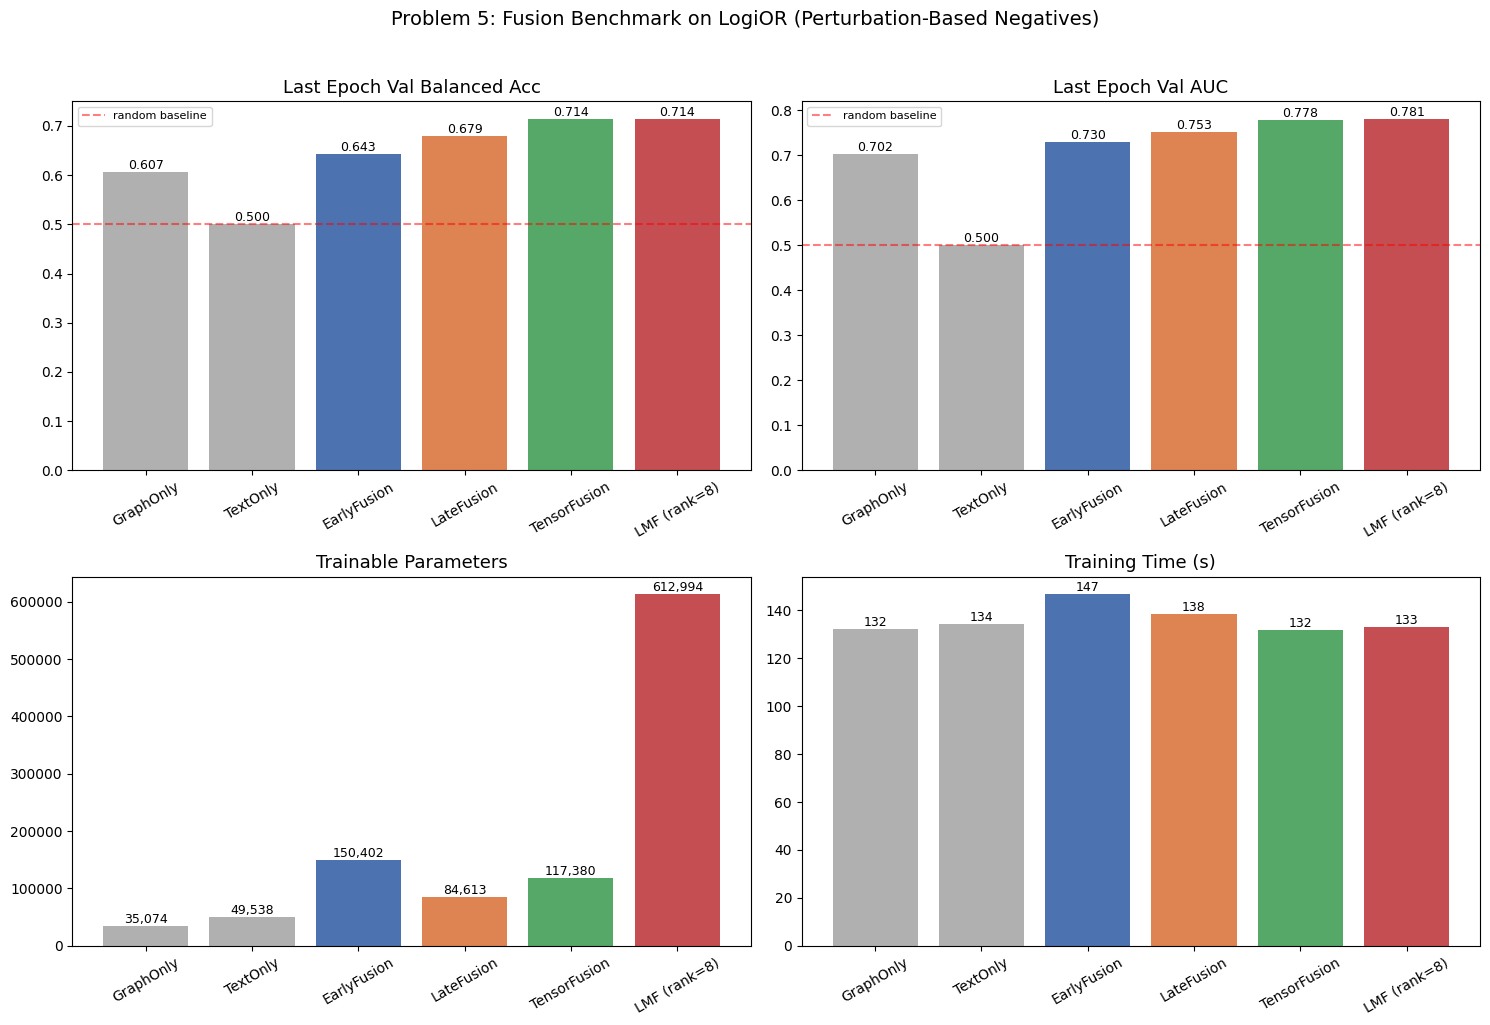

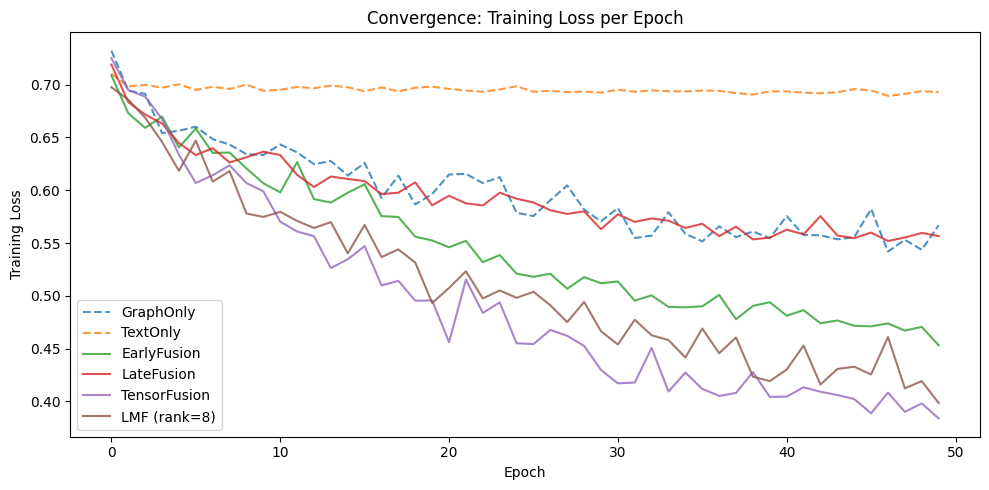

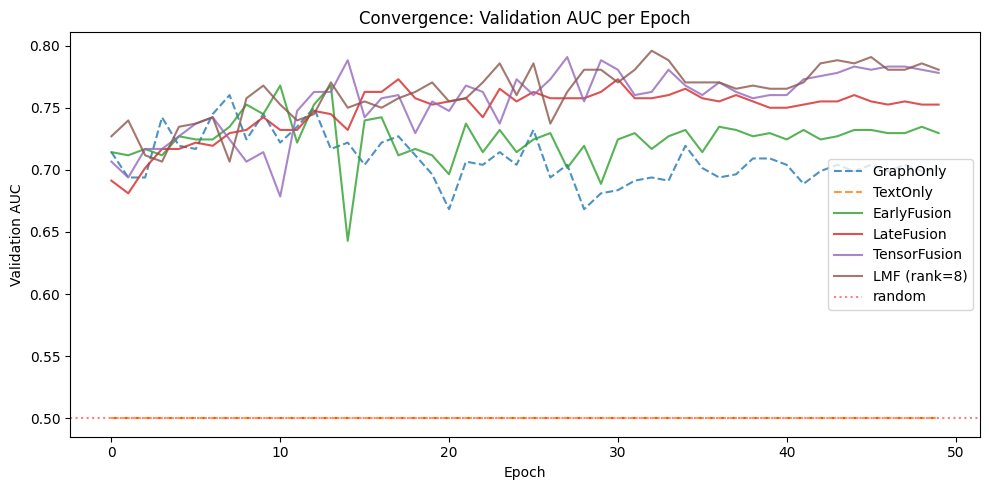

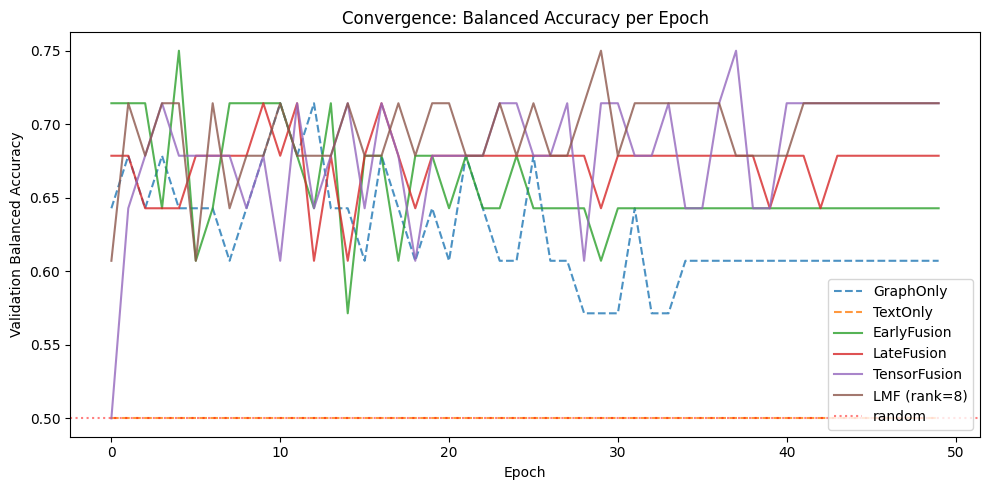

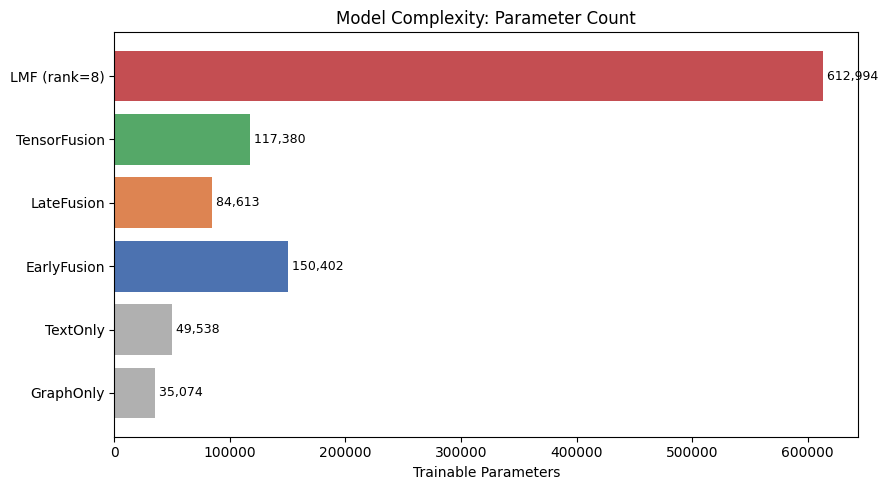

In [10]:
# Grey for baselines, colored for fusion methods
colors_map = {
    'GraphOnly': '#B0B0B0', 'TextOnly': '#B0B0B0',
    'EarlyFusion': '#4C72B0', 'LateFusion': '#DD8452',
    'TensorFusion': '#55A868', 'LMF (rank=8)': '#C44E52',
}
names = list(all_results.keys())
colors = [colors_map.get(n, '#999999') for n in names]


# ── 1. Bar charts: Balanced Acc, AUC, Params, Time ──
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_keys = ['val_bal_acc', 'val_auc', 'params', 'time_sec']
titles = ['Last Epoch Val Balanced Acc', 'Last Epoch Val AUC', 'Trainable Parameters', 'Training Time (s)']

for i, (key, title) in enumerate(zip(metrics_keys, titles)):
    ax = axes.flatten()[i]
    
    vals = []
    for n in names:
        if key in ['val_bal_acc', 'val_auc']:
            vals.append(all_results[n]['history'][key][-1])
        else:
            vals.append(all_results[n][key])
            
    ax.bar(names, vals, color=colors)
    ax.set_title(title, fontsize=13)
    
    for j, v in enumerate(vals):
        fmt = f'{v:.3f}' if isinstance(v, float) and v < 10 else f'{v:,.0f}'
        ax.text(j, v, fmt, ha='center', va='bottom', fontsize=9)
        
    ax.tick_params(axis='x', rotation=30)
    if 'Acc' in title or 'AUC' in title:
        ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='random baseline')
        ax.legend(fontsize=8)

plt.suptitle('Problem 5: Fusion Benchmark on LogiOR (Perturbation-Based Negatives)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('p5_fusion_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 2. Training loss convergence ──
fig, ax = plt.subplots(figsize=(10, 5))
for name, res in all_results.items():
    ls = '--' if name in ('GraphOnly', 'TextOnly') else '-'
    ax.plot(res['history']['train_loss'], label=name, alpha=0.8, linestyle=ls)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Convergence: Training Loss per Epoch')
ax.legend()
plt.tight_layout()
plt.savefig('p5_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 3. Validation AUC convergence ──
fig, ax = plt.subplots(figsize=(10, 5))
for name, res in all_results.items():
    ls = '--' if name in ('GraphOnly', 'TextOnly') else '-'
    ax.plot(res['history']['val_auc'], label=name, alpha=0.8, linestyle=ls)
ax.axhline(y=0.5, color='red', linestyle=':', alpha=0.5, label='random')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation AUC')
ax.set_title('Convergence: Validation AUC per Epoch')
ax.legend()
plt.tight_layout()
plt.savefig('p5_val_auc.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 4. Validation balanced accuracy convergence ──
fig, ax = plt.subplots(figsize=(10, 5))
for name, res in all_results.items():
    ls = '--' if name in ('GraphOnly', 'TextOnly') else '-'
    ax.plot(res['history']['val_bal_acc'], label=name, alpha=0.8, linestyle=ls)
ax.axhline(y=0.5, color='red', linestyle=':', alpha=0.5, label='random')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Balanced Accuracy')
ax.set_title('Convergence: Balanced Accuracy per Epoch')
ax.legend()
plt.tight_layout()
plt.savefig('p5_bal_acc.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 5. Parameter count comparison ──
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(names, [all_results[n]['params'] for n in names], color=colors)
ax.set_xlabel('Trainable Parameters')
ax.set_title('Model Complexity: Parameter Count')
for i, n in enumerate(names):
    v = all_results[n]['params']
    ax.text(v, i, f' {v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('p5_params.png', dpi=150, bbox_inches='tight')
plt.show()

### Write-Up: Best Validation Accuracies & Analysis

Best Validation Accuracies are written in the beginning

Why perturbation-based negatives?
We used perturbation-based negatives (like flipping the objective or changing variable types) instead of random mismatches because random pairs are too easy. If we just randomly pair a graph with an unrelated text, the model can guess the answer using obvious clues like vocabulary or problem size. By slightly modifying the correct graphs (hard negatives), we force the model to actually learn the fine-grained logical alignment between the text and the graph.

Which technique is best for this dataset and why?
Tensor Fusion and LMF should be the best methods for this task.

Unimodal models perform poorly: "TextOnly" gets confused because the text is identical for both positive and negative pairs. "GraphOnly" can see the graph changes, but without the text, it doesn't know what the correct structure is supposed to be. So after training for more epoches, the accuracy goes down.

Late Fusion also struggles because the graph and text features don't interact until the very end classifier.

Tensor Fusion and LMF work best because they use outer products to explicitly model cross-modal interactions. This allows the model to directly compare specific text features (e.g., the word "minimize") with specific graph features (e.g., a "max" objective node) to easily catch the inconsistencies we introduced in the negative samples.

Visualizations: All required charts (bar charts for accuracy/AUC/parameters, and training curves for loss/accuracy) are plotted in the cells above. Baseline performances are included as dashed lines for comparison.

# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [11]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to C:\Users\PR-N\AppData\Local\Temp\pip-req-build-qz0hnczh
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\PR-N\AppData\Local\Temp\pip-req-build-qz0hnczh'


In [12]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

First, we create the model.

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [14]:
image_filename = "../HW2/smiling_person.png" # REPLACE WITH YOUR FILE
image = Image.open(image_filename).convert("RGB")

Now, we will prepare the prompt to use.

In [15]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [16]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
     a photo of a happy person: 88.09%
       a photo of a sad person: 6.19%
    a photo of an angry person: 5.72%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [17]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool, global_add_pool
from torch_geometric.data import Data, Batch as PyGBatch
from transformers import AutoTokenizer, AutoModel


class GraphEncoderCL(nn.Module):
    """
    Hybrid graph encoder:
      1) BatchNorm on raw node features → GCN → attention-weighted pooling
      2) Graph-level structural statistics (handcrafted, highly discriminative)
      3) Combine both into final embedding
    """
    def __init__(self, in_dim, hidden_dim=128, out_dim=128, num_layers=3,
                 dropout=0.4, n_stats=15):
        super().__init__()
        self.input_norm = nn.BatchNorm1d(in_dim)
        dims = [in_dim] + [hidden_dim] * (num_layers - 1) + [hidden_dim]
        self.convs = nn.ModuleList(
            [GCNConv(dims[i], dims[i+1]) for i in range(len(dims)-1)]
        )
        self.norms = nn.ModuleList([nn.LayerNorm(d) for d in dims[1:]])
        self.dropout = dropout
        self.edge_drop = 0.1
        self.attn_gate = nn.Sequential(nn.Linear(hidden_dim, 1), nn.Sigmoid())
        self.stats_proj = nn.Sequential(
            nn.Linear(n_stats, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
        )
        self.combine = nn.Sequential(
            nn.Linear(hidden_dim * 3 + hidden_dim, out_dim),
            nn.LayerNorm(out_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim),
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.input_norm(x)
        if self.training and self.edge_drop > 0 and edge_index.size(1) > 0:
            mask = torch.rand(edge_index.size(1), device=edge_index.device) > self.edge_drop
            edge_index = edge_index[:, mask]
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        attn_weights = self.attn_gate(x)
        z_attn = global_add_pool(x * attn_weights, batch)
        z_mean = global_mean_pool(x, batch)
        z_max  = global_max_pool(x, batch)
        z_stats = self.stats_proj(data.graph_stats)
        z = torch.cat([z_attn, z_mean, z_max, z_stats], dim=-1)
        return self.combine(z)


class TextEncoderCL(nn.Module):
    def __init__(self, model_name='sentence-transformers/all-MiniLM-L6-v2',
                 out_dim=128, max_length=256, dropout=0.3):
        super().__init__()
        self.tok = AutoTokenizer.from_pretrained(model_name)
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden = self.backbone.config.hidden_size  # 384

        for p in self.backbone.parameters():
            p.requires_grad = False
        for name, p in self.backbone.named_parameters():
            if 'encoder.layer.4' in name or 'encoder.layer.5' in name:
                p.requires_grad = True

        self.proj = nn.Sequential(
            nn.Linear(hidden, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, out_dim),
        )
        self.max_length = max_length

    def forward(self, texts, device=None):
        if device is None:
            device = next(self.parameters()).device
        enc = self.tok(texts, padding=True, truncation=True,
                       max_length=self.max_length, return_tensors='pt').to(device)
        h = self.backbone(**enc).last_hidden_state
        mask = enc['attention_mask'].unsqueeze(-1).float()
        pooled = (h * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        return self.proj(pooled)


class CLModel(nn.Module):
    def __init__(self, dim_graph, embedded_dim=128, temp=0.07, n_stats=15):
        super().__init__()
        self.encoder_graph = GraphEncoderCL(
            in_dim=dim_graph, hidden_dim=128, out_dim=embedded_dim,
            num_layers=3, dropout=0.4, n_stats=n_stats,
        )
        self.encoder_text = TextEncoderCL(out_dim=embedded_dim, dropout=0.3)

        self.projector_graph = nn.Linear(embedded_dim, embedded_dim)
        self.projector_text = nn.Linear(embedded_dim, embedded_dim)

        self.register_buffer('logit_scale', torch.tensor(np.log(1/0.07)))

    def forward(self, graph_batch, texts):
        device = next(self.parameters()).device
        z_g = self.encoder_graph(graph_batch)
        z_t = self.encoder_text(texts, device=device)
        z_g = self.projector_graph(z_g)
        z_t = self.projector_text(z_t)
        z_g = F.normalize(z_g, dim=-1)
        z_t = F.normalize(z_t, dim=-1)
        return z_g, z_t

    def encode_graph_only(self, graph_batch):
        z_g = self.encoder_graph(graph_batch)
        z_g = self.projector_graph(z_g)
        return F.normalize(z_g, dim=-1)


class ContrastiveLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

    def forward(self, z_g, z_t, logit_scale, z_g_neg=None):
        B = z_g.size(0)
        scale = logit_scale.exp().clamp(max=20.0)

        if z_g_neg is not None:
            z_g_all = torch.cat([z_g, z_g_neg], dim=0)
            logits_g2t = torch.einsum('id, jd -> ij', z_g_all, z_t) * scale
            labels_g2t = torch.arange(B, device=z_g.device)
            loss_g2t = self.loss_fn(logits_g2t[:B], labels_g2t)

            logits_t2g = torch.einsum('id, jd -> ij', z_t, z_g_all) * scale
            loss_t2g = self.loss_fn(logits_t2g, labels_g2t)
        else:
            logits = torch.einsum('id, jd -> ij', z_g, z_t) * scale
            labels = torch.arange(B, device=z_g.device)
            loss_g2t = self.loss_fn(logits, labels)
            loss_t2g = self.loss_fn(logits.T, labels)

        return (loss_g2t + loss_t2g) / 2


In [18]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import copy


def train_contrastive(model, criterion, train_loader, val_loader,
                      num_epochs=120, lr=1e-3, device='cuda', patience=30,
                      accum_steps=2, warmup_epochs=5):
    
    model.to(device)

    backbone_params = []
    other_params = []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if 'backbone' in name:
            backbone_params.append(p)
        else:
            other_params.append(p)

    print(f"  Backbone trainable params: {sum(p.numel() for p in backbone_params):,}")
    print(f"  Other trainable params:    {sum(p.numel() for p in other_params):,}")

    optimizer = optim.AdamW([
        {'params': backbone_params, 'lr': lr * 0.1, 'weight_decay': 1e-2},
        {'params': other_params,    'lr': lr,        'weight_decay': 5e-2},
    ])

    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=30, T_mult=1, eta_min=1e-5)

    history = {'train_loss': [], 'val_loss': [], 'val_r1': []}
    best_r1, best_state, no_improve = 0.0, None, 0

    for epoch in range(num_epochs):
        # ── Train ──
        model.train()
        total_loss, n_batches = 0.0, 0
        optimizer.zero_grad()

        for step, batch in enumerate(train_loader):
            g = batch['graph'].to(device)
            texts = batch['text']
            z_g, z_t = model(g, texts)

            # encode hard negative graph
            z_g_neg = None
            if 'neg_graph' in batch:
                neg_g = batch['neg_graph'].to(device)
                z_g_neg = model.encode_graph_only(neg_g)

            loss = criterion(z_g, z_t, model.logit_scale, z_g_neg=z_g_neg) / accum_steps
            loss.backward()

            if (step + 1) % accum_steps == 0 or (step + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                optimizer.zero_grad()

            total_loss += loss.item() * accum_steps
            n_batches += 1

        scheduler.step()
        avg_train = total_loss / max(n_batches, 1)

        # ── Validate ──
        model.eval()
        val_loss_sum, val_n = 0.0, 0
        all_zg, all_zt = [], []
        with torch.no_grad():
            for batch in val_loader:
                g = batch['graph'].to(device)
                texts = batch['text']
                z_g, z_t = model(g, texts)
                val_loss_sum += criterion(z_g, z_t, model.logit_scale).item()
                val_n += 1
                all_zg.append(z_g.cpu())
                all_zt.append(z_t.cpu())
        avg_val = val_loss_sum / max(val_n, 1)

        all_zg = torch.cat(all_zg)
        all_zt = torch.cat(all_zt)
        sims = torch.einsum('id, jd -> ij', all_zg, all_zt)
        r1 = (sims.argmax(dim=1) == torch.arange(len(all_zg))).float().mean().item()

        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_r1'].append(r1)

        if r1 > best_r1:
            best_r1 = r1
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Ep {epoch+1:3d}/{num_epochs} | "
                  f"tr={avg_train:.4f} val={avg_val:.4f} | "
                  f"R@1={r1:.3f} best={best_r1:.3f} | "
                  f"τ={model.logit_scale.exp().clamp(max=100).item():.1f} "
                  f"lr={optimizer.param_groups[1]['lr']:.1e}")

        if no_improve >= patience:
            print(f"Early stop at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best model (val R@1={best_r1:.3f})")
    return history


In [19]:
@torch.no_grad()
def evaluate_alignment(model, loader, device='cuda', tag='Test'):
    """Compute R@1, R@3, R@5, MRR for graph→text retrieval."""
    model.eval()
    all_zg, all_zt = [], []
    for batch in loader:
        g = batch['graph'].to(device)
        z_g, z_t = model(g, batch['text'])
        all_zg.append(z_g.cpu())
        all_zt.append(z_t.cpu())
    all_zg = torch.cat(all_zg)
    all_zt = torch.cat(all_zt)
    N = len(all_zg)

    sims = torch.einsum('id, jd -> ij', all_zg, all_zt)
    ranks = (sims.argsort(dim=1, descending=True) == torch.arange(N).unsqueeze(1)
             ).nonzero(as_tuple=True)[1].float()
    r1  = (ranks < 1).float().mean().item()
    r3  = (ranks < 3).float().mean().item()
    r5  = (ranks < 5).float().mean().item()
    mrr = (1.0 / (ranks + 1)).mean().item()

    print(f"[{tag}] N={N} | R@1={r1:.3f} | R@3={r3:.3f} | R@5={r5:.3f} | MRR={mrr:.3f}")
    return {'r1': r1, 'r3': r3, 'r5': r5, 'mrr': mrr, 'sims': sims, 'zg': all_zg, 'zt': all_zt}


@torch.no_grad()
def predict_best_match(model, graph_data, candidate_texts, device='cuda'):
    """Zero-shot: given one graph, find best-matching text."""
    model.eval()
    g_batch = PyGBatch.from_data_list([graph_data]).to(device)
    z_g = model.encoder_graph(g_batch)
    z_g = F.normalize(model.projector_graph(z_g), dim=-1)
    z_t = model.encoder_text(candidate_texts, device=device)
    z_t = F.normalize(model.projector_text(z_t), dim=-1)
    scores = torch.einsum('id, jd -> ij', z_g, z_t)
    best_idx = scores.argmax().item()
    print(f"Best match: index {best_idx} | score {scores[0, best_idx].item():.4f}")
    return best_idx, scores


### Build Dataset for Contrastive Alignment

Again, the data load is from teammembers. Encoders, negative pair considerations are from discussion with team members. 

In [20]:
import os, re, json, random, copy
import numpy as np
import torch
from pathlib import Path
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data, Batch as PyGBatch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_nb_dir = Path(os.path.abspath('')).resolve()
HW2_ROOT = _nb_dir if (_nb_dir / 'data').exists() else _nb_dir.parent
DATA_DIR = HW2_ROOT / 'data'
GRAPHS_CL_DIR = DATA_DIR / 'graphs_cl'
GRAPHS_CL_DIR.mkdir(exist_ok=True)

DATASETS = ['LogiOR', 'IndustryOR', 'NLP4LP', 'ComplexOR']
print(f'HW2_ROOT: {HW2_ROOT}')

# ── Step 1: Convert MPS → bipartite graph JSON (if not done) ──

def _safe_float(v, default=0.0):
    try:
        f = float(v)
        return f if np.isfinite(f) else default
    except (TypeError, ValueError):
        return default

def _mps_to_graph_json(mps_path):
    import gurobipy as gp
    m = gp.read(str(mps_path))
    m.setParam('OutputFlag', 0)
    m.update()
    vars_ = m.getVars()
    cons_ = m.getConstrs()
    A = m.getA()
    var_nodes = [{'id': v.VarName, 'type': 'var', 'vtype': v.VType,
                  'lb': _safe_float(v.LB), 'ub': _safe_float(v.UB),
                  'obj': float(v.Obj)} for v in vars_]
    con_nodes = [{'id': c.ConstrName, 'type': 'constr', 'sense': c.Sense,
                  'rhs': float(c.RHS)} for c in cons_]
    edges = []
    Acoo = A.tocoo()
    for r, c, val in zip(Acoo.row, Acoo.col, Acoo.data):
        edges.append({'src': cons_[r].ConstrName, 'dst': vars_[c].VarName, 'coef': float(val)})
    obj_id = '__OBJ__'
    con_nodes.append({'id': obj_id, 'type': 'obj',
                      'sense': 'min' if m.ModelSense == 1 else 'max', 'rhs': 0.0})
    for v in vars_:
        if v.Obj != 0.0:
            edges.append({'src': obj_id, 'dst': v.VarName, 'coef': float(v.Obj)})
    return {'meta': {'num_vars': len(vars_), 'num_constrs': len(con_nodes),
                     'num_edges': len(edges)},
            'nodes': {'vars': var_nodes, 'constrs': con_nodes}, 'edges': edges}

total_converted = 0
for ds_name in DATASETS:
    mps_dir = DATA_DIR / 'mps_consistency' / ds_name
    out_dir = GRAPHS_CL_DIR / ds_name
    out_dir.mkdir(exist_ok=True)
    if not mps_dir.exists():
        print(f'  {ds_name}: mps_consistency dir not found, skipping')
        continue
    existing = len(list(out_dir.glob('*_graph.json')))
    mps_files = sorted(mps_dir.glob('*.mps'))
    if existing >= len(mps_files):
        print(f'  {ds_name}: {existing} graphs already converted')
        total_converted += existing
        continue
    converted = 0
    for mp in mps_files:
        gout = out_dir / f'{mp.stem}_graph.json'
        if gout.exists():
            converted += 1
            continue
        try:
            g = _mps_to_graph_json(mp)
            with open(gout, 'w', encoding='utf-8') as f:
                json.dump(g, f, allow_nan=False)
            converted += 1
        except Exception as e:
            print(f'  WARN: {mp.name}: {e}')
    print(f'  {ds_name}: {converted} graphs')
    total_converted += converted
print(f'Total graphs available: {total_converted}')


# ── Step 2: Build PyG graph from JSON ──

@dataclass
class GraphBuildCfg:
    log_coef: bool = True

def _build_pyg_graph(gd, cfg=None):
    cfg = cfg or GraphBuildCfg()
    vtype_map = {'C': 0, 'I': 1, 'B': 2}
    sense_map = {'<': -1, '>': 1, '=': 0}
    id2idx, feats = {}, []
    for v in gd['nodes']['vars']:
        id2idx[v['id']] = len(id2idx)
        lb = _safe_float(v.get('lb'), 0)
        ub = min(_safe_float(v.get('ub'), 1e6), 1e6)
        obj = _safe_float(v.get('obj'), 0)
        vt = vtype_map.get(v.get('vtype', 'C'), 0)
        feats.append([lb, ub, obj, vt, 1.0, 0.0])
    for c in gd['nodes']['constrs']:
        id2idx[c['id']] = len(id2idx)
        s = sense_map.get(c.get('sense', '='), 0)
        rhs = _safe_float(c.get('rhs'), 0)
        feats.append([s, rhs, 0, 0, 0.0, 1.0])
    src, dst, attr = [], [], []
    for e in gd['edges']:
        if e['src'] in id2idx and e['dst'] in id2idx:
            si, di = id2idx[e['src']], id2idx[e['dst']]
            c = _safe_float(e.get('coef'), 0)
            if cfg.log_coef:
                c = np.sign(c) * np.log1p(abs(c))
            src += [si, di]; dst += [di, si]; attr += [c, c]
    x = torch.tensor(feats, dtype=torch.float32)
    deg = torch.zeros(x.size(0))
    if src:
        ei = torch.tensor([src, dst], dtype=torch.long)
        ea = torch.tensor(attr, dtype=torch.float32).unsqueeze(-1)
        for s in src:
            deg[s] += 1
    else:
        ei = torch.zeros(2, 0, dtype=torch.long)
        ea = torch.zeros(0, 1)
    x = torch.cat([x, deg.unsqueeze(-1)], dim=-1)
    return Data(x=x, edge_index=ei, edge_attr=ea)


N_GRAPH_STATS = 15

def _compute_graph_stats(gd):
    vars_list = gd['nodes']['vars']
    cons_list = gd['nodes']['constrs']
    edges_list = gd['edges']
    n_vars = len(vars_list)
    n_cons = len(cons_list)
    n_edges = len(edges_list)
    vtypes = [v.get('vtype', 'C') for v in vars_list]
    frac_bin = sum(1 for vt in vtypes if vt == 'B') / max(n_vars, 1)
    frac_int = sum(1 for vt in vtypes if vt == 'I') / max(n_vars, 1)
    obj_coefs = [abs(_safe_float(v.get('obj'), 0)) for v in vars_list]
    mean_obj = np.mean(obj_coefs) if obj_coefs else 0.0
    std_obj  = np.std(obj_coefs)  if obj_coefs else 0.0
    rhs_vals = [abs(_safe_float(c.get('rhs'), 0)) for c in cons_list]
    mean_rhs = np.mean(rhs_vals) if rhs_vals else 0.0
    std_rhs  = np.std(rhs_vals)  if rhs_vals else 0.0
    edge_coefs = [abs(_safe_float(e.get('coef'), 0)) for e in edges_list]
    mean_ecoef = np.mean(edge_coefs) if edge_coefs else 0.0
    std_ecoef  = np.std(edge_coefs)  if edge_coefs else 0.0
    lbs = [_safe_float(v.get('lb'), 0) for v in vars_list]
    ubs = [min(_safe_float(v.get('ub'), 1e6), 1e6) for v in vars_list]
    mean_lb = np.mean(lbs) if lbs else 0.0
    mean_ub = np.mean(ubs) if ubs else 0.0
    obj_sense = 1.0
    for c in cons_list:
        if c.get('id') == '__OBJ__' or c.get('type') == 'obj':
            obj_sense = 1.0 if c.get('sense') == 'min' else -1.0
            break
    density = n_edges / (n_vars * n_cons + 1)
    stats = [
        np.log1p(n_vars), np.log1p(n_cons), np.log1p(n_edges), density,
        frac_bin, frac_int,
        np.log1p(mean_obj), np.log1p(std_obj),
        np.log1p(mean_rhs), np.log1p(std_rhs),
        np.log1p(mean_ecoef), np.log1p(std_ecoef),
        np.log1p(abs(mean_lb)), np.log1p(min(mean_ub, 1e6)),
        obj_sense,
    ]
    return torch.tensor(stats, dtype=torch.float32)


# Graph Perturbation function (idea from problem 5)
# each positive pair (graph, text) come with a perturbed graph as hard negative

def _perturb_sense(g):
    """<= <-> >="""
    g = copy.deepcopy(g)
    flip = {'<': '>', '>': '<'}
    for c in g['nodes']['constrs']:
        if c.get('sense') in flip:
            c['sense'] = flip[c['sense']]
    return g

def _perturb_vtype(g):
    """B->C, I->B, C->I"""
    g = copy.deepcopy(g)
    swap = {'B': 'C', 'I': 'B', 'C': 'I'}
    for v in g['nodes']['vars']:
        v['vtype'] = swap.get(v.get('vtype', 'C'), v.get('vtype', 'C'))
    return g

def _perturb_obj(g):
    """min<->max"""
    g = copy.deepcopy(g)
    flip_sense = {'min': 'max', 'max': 'min'}
    for c in g['nodes']['constrs']:
        if c.get('id') == '__OBJ__' or c.get('type') == 'obj':
            c['sense'] = flip_sense.get(c.get('sense', 'min'), 'max')
    for v in g['nodes']['vars']:
        v['obj'] = -v.get('obj', 0.0)
    if 'meta' in g and 'model_sense' in g['meta']:
        g['meta']['model_sense'] = flip_sense.get(g['meta']['model_sense'], 'max')
    return g

_PERTURBATIONS = [_perturb_sense, _perturb_vtype, _perturb_obj]


# ── Step 3: Collect all (graph_json, text) pairs ──

all_pairs = []
for ds_name in DATASETS:
    text_dir = DATA_DIR / ds_name
    graph_dir = GRAPHS_CL_DIR / ds_name
    if not text_dir.exists() or not graph_dir.exists():
        continue
    for gpath in sorted(graph_dir.glob('*_graph.json')):
        prob_id = gpath.stem.replace('_graph', '')
        tpath = text_dir / prob_id / 'question.txt'
        if not tpath.exists():
            continue
        with open(gpath, 'r', encoding='utf-8') as f:
            graph_dict = json.load(f)
        with open(tpath, 'r', encoding='utf-8') as f:
            text = f.read().strip()
        if len(text) < 20:
            continue
        all_pairs.append({
            'graph_dict': graph_dict, 'text': text,
            'prob': f'{ds_name}/{prob_id}', 'dataset': ds_name
        })

print(f'\nTotal positive pairs: {len(all_pairs)}')
for ds in DATASETS:
    n = sum(1 for p in all_pairs if p['dataset'] == ds)
    print(f'  {ds}: {n}')

# ── Step 4: Split ──

SEED, TRAIN_FRAC, VAL_FRAC = 42, 0.70, 0.15
rng = random.Random(SEED)
shuffled = all_pairs[:]
rng.shuffle(shuffled)
n = len(shuffled)
n_train = int(round(TRAIN_FRAC * n))
n_val = int(round(VAL_FRAC * n))
train_pairs = shuffled[:n_train]
val_pairs   = shuffled[n_train:n_train + n_val]
test_pairs  = shuffled[n_train + n_val:]


class PositivePairDataset(Dataset):
    def __init__(self, pairs, max_text_chars=8000, use_hard_neg=False):
        self.pairs = pairs
        self.max_text_chars = max_text_chars
        self.use_hard_neg = use_hard_neg  # ★ 只在训练集开启

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ex = self.pairs[idx]
        graph = _build_pyg_graph(ex['graph_dict'])
        stats = _compute_graph_stats(ex['graph_dict'])
        graph.graph_stats = stats.unsqueeze(0)
        text = ex['text'][:self.max_text_chars]

        result = {'graph': graph, 'text': text, 'prob': ex['prob']}

        # randomly choose a perturbation to generate negative pairs
        if self.use_hard_neg:
            perturb_fn = random.choice(_PERTURBATIONS)
            neg_dict = perturb_fn(ex['graph_dict'])
            neg_graph = _build_pyg_graph(neg_dict)
            neg_stats = _compute_graph_stats(neg_dict)
            neg_graph.graph_stats = neg_stats.unsqueeze(0)
            result['neg_graph'] = neg_graph

        return result


def collate_positive(batch):
    out = {
        'graph': PyGBatch.from_data_list([b['graph'] for b in batch]),
        'text':  [b['text'] for b in batch],
        'prob':  [b['prob'] for b in batch],
    }
    if 'neg_graph' in batch[0]:
        out['neg_graph'] = PyGBatch.from_data_list([b['neg_graph'] for b in batch])
    return out


CL_BATCH_SIZE = 32
train_ds_cl = PositivePairDataset(train_pairs, use_hard_neg=True)   # ★ for training, use hard neg
val_ds_cl   = PositivePairDataset(val_pairs,   use_hard_neg=False)
test_ds_cl  = PositivePairDataset(test_pairs,  use_hard_neg=False)

cl_train_loader = DataLoader(train_ds_cl, batch_size=CL_BATCH_SIZE, shuffle=True,
                             collate_fn=collate_positive, drop_last=True)
cl_val_loader   = DataLoader(val_ds_cl,   batch_size=CL_BATCH_SIZE, shuffle=False,
                             collate_fn=collate_positive)
cl_test_loader  = DataLoader(test_ds_cl,  batch_size=CL_BATCH_SIZE, shuffle=False,
                             collate_fn=collate_positive)

NODE_FEAT_DIM_CL = train_ds_cl[0]['graph'].x.size(1)

sample = train_ds_cl[0]['graph']
print(f'\nNode feat dim: {NODE_FEAT_DIM_CL}')
print(f'Graph stats shape: {sample.graph_stats.shape} (should be [1, {N_GRAPH_STATS}])')
print(f'Train: {len(train_ds_cl)} | Val: {len(val_ds_cl)} | Test: {len(test_ds_cl)}')
print(f'Batch size: {CL_BATCH_SIZE}')
print(f'Hard negatives: ENABLED for training')

sample_stats = sample.graph_stats.squeeze()
stat_names = ['log_nvars', 'log_ncons', 'log_nedges', 'density',
              'frac_bin', 'frac_int', 'log_mean_obj', 'log_std_obj',
              'log_mean_rhs', 'log_std_rhs', 'log_mean_ecoef', 'log_std_ecoef',
              'log_mean_lb', 'log_mean_ub', 'obj_sense']
print('\nSample graph stats:')
for name, val in zip(stat_names, sample_stats.tolist()):
    print(f'  {name:18s}: {val:.4f}')


HW2_ROOT: C:\Users\PR-N\Documents\GitHub\MMAI2026\HW2
  LogiOR: 92 graphs already converted
  IndustryOR: 83 graphs already converted
  NLP4LP: 264 graphs already converted
  ComplexOR: 18 graphs already converted
Total graphs available: 457

Total positive pairs: 457
  LogiOR: 92
  IndustryOR: 83
  NLP4LP: 264
  ComplexOR: 18

Node feat dim: 7
Graph stats shape: torch.Size([1, 15]) (should be [1, 15])
Train: 320 | Val: 69 | Test: 68
Batch size: 32
Hard negatives: ENABLED for training

Sample graph stats:
  log_nvars         : 1.6094
  log_ncons         : 1.9459
  log_nedges        : 2.7081
  density           : 0.5600
  frac_bin          : 0.0000
  frac_int          : 0.5000
  log_mean_obj      : 3.8286
  log_std_obj       : 3.1744
  log_mean_rhs      : 6.9137
  log_std_rhs       : 7.6073
  log_mean_ecoef    : 3.0134
  log_std_ecoef     : 3.2369
  log_mean_lb       : 0.0000
  log_mean_ub       : 1.7918
  obj_sense         : 1.0000


### Train Contrastive Model

In [21]:
EMBED_DIM = 64
NUM_EPOCHS = 120
LR = 1e-3

cl_model = CLModel(
    dim_graph=NODE_FEAT_DIM_CL,
    embedded_dim=EMBED_DIM,
    temp=0.07,
    n_stats=N_GRAPH_STATS,
).to(device)

criterion = ContrastiveLoss()

n_trainable = sum(p.numel() for p in cl_model.parameters() if p.requires_grad)
print(f"Trainable params: {n_trainable:,}  (backbone is FROZEN)")
print(f"Train batches/epoch: {len(cl_train_loader)}")
print(f"Effective batch size: {CL_BATCH_SIZE} x 2 (accum) = {CL_BATCH_SIZE * 2}")
print(f"Device: {device}\n")

history = train_contrastive(
    cl_model, criterion,
    cl_train_loader, cl_val_loader,
    num_epochs=NUM_EPOCHS, lr=LR, device=device,
    patience=30,
    accum_steps=2,
    warmup_epochs=5,
)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1287.26it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 3,813,455  (backbone is FROZEN)
Train batches/epoch: 10
Effective batch size: 32 x 2 (accum) = 64
Device: cuda

  Backbone trainable params: 3,548,928
  Other trainable params:    264,527


c:\Users\PR-N\Documents\GitHub\MMAI2026\HW2\.venv\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Ep   1/120 | tr=4.2114 val=2.8420 | R@1=0.014 best=0.014 | τ=14.3 lr=1.0e-03
Ep   5/120 | tr=3.4649 val=2.6861 | R@1=0.043 best=0.043 | τ=14.3 lr=9.3e-04
Ep  10/120 | tr=3.2683 val=2.5515 | R@1=0.101 best=0.101 | τ=14.3 lr=7.5e-04
Ep  15/120 | tr=3.1373 val=2.5858 | R@1=0.058 best=0.101 | τ=14.3 lr=5.1e-04
Ep  20/120 | tr=2.9495 val=2.5758 | R@1=0.101 best=0.101 | τ=14.3 lr=2.6e-04
Ep  25/120 | tr=2.8365 val=2.6847 | R@1=0.058 best=0.101 | τ=14.3 lr=7.6e-05
Ep  30/120 | tr=2.7976 val=2.6497 | R@1=0.058 best=0.101 | τ=14.3 lr=1.0e-03
Ep  35/120 | tr=2.6670 val=2.6671 | R@1=0.087 best=0.130 | τ=14.3 lr=9.3e-04
Ep  40/120 | tr=2.3359 val=2.7511 | R@1=0.145 best=0.145 | τ=14.3 lr=7.5e-04
Ep  45/120 | tr=2.1251 val=2.5112 | R@1=0.101 best=0.174 | τ=14.3 lr=5.1e-04
Ep  50/120 | tr=1.9852 val=2.4254 | R@1=0.159 best=0.174 | τ=14.3 lr=2.6e-04
Ep  55/120 | tr=1.9123 val=2.3454 | R@1=0.159 best=0.203 | τ=14.3 lr=7.6e-05
Ep  60/120 | tr=1.9288 val=2.3687 | R@1=0.159 best=0.217 | τ=14.3 lr=1.0e-03

### Evaluate Alignment

In [22]:
val_metrics = evaluate_alignment(cl_model, cl_val_loader, device=device, tag='Val')
test_metrics = evaluate_alignment(cl_model, cl_test_loader, device=device, tag='Test')

[Val] N=69 | R@1=0.275 | R@3=0.449 | R@5=0.594 | MRR=0.421
[Test] N=68 | R@1=0.250 | R@3=0.456 | R@5=0.647 | MRR=0.416


### Visualizations (Q3 alignment success/failure examples)

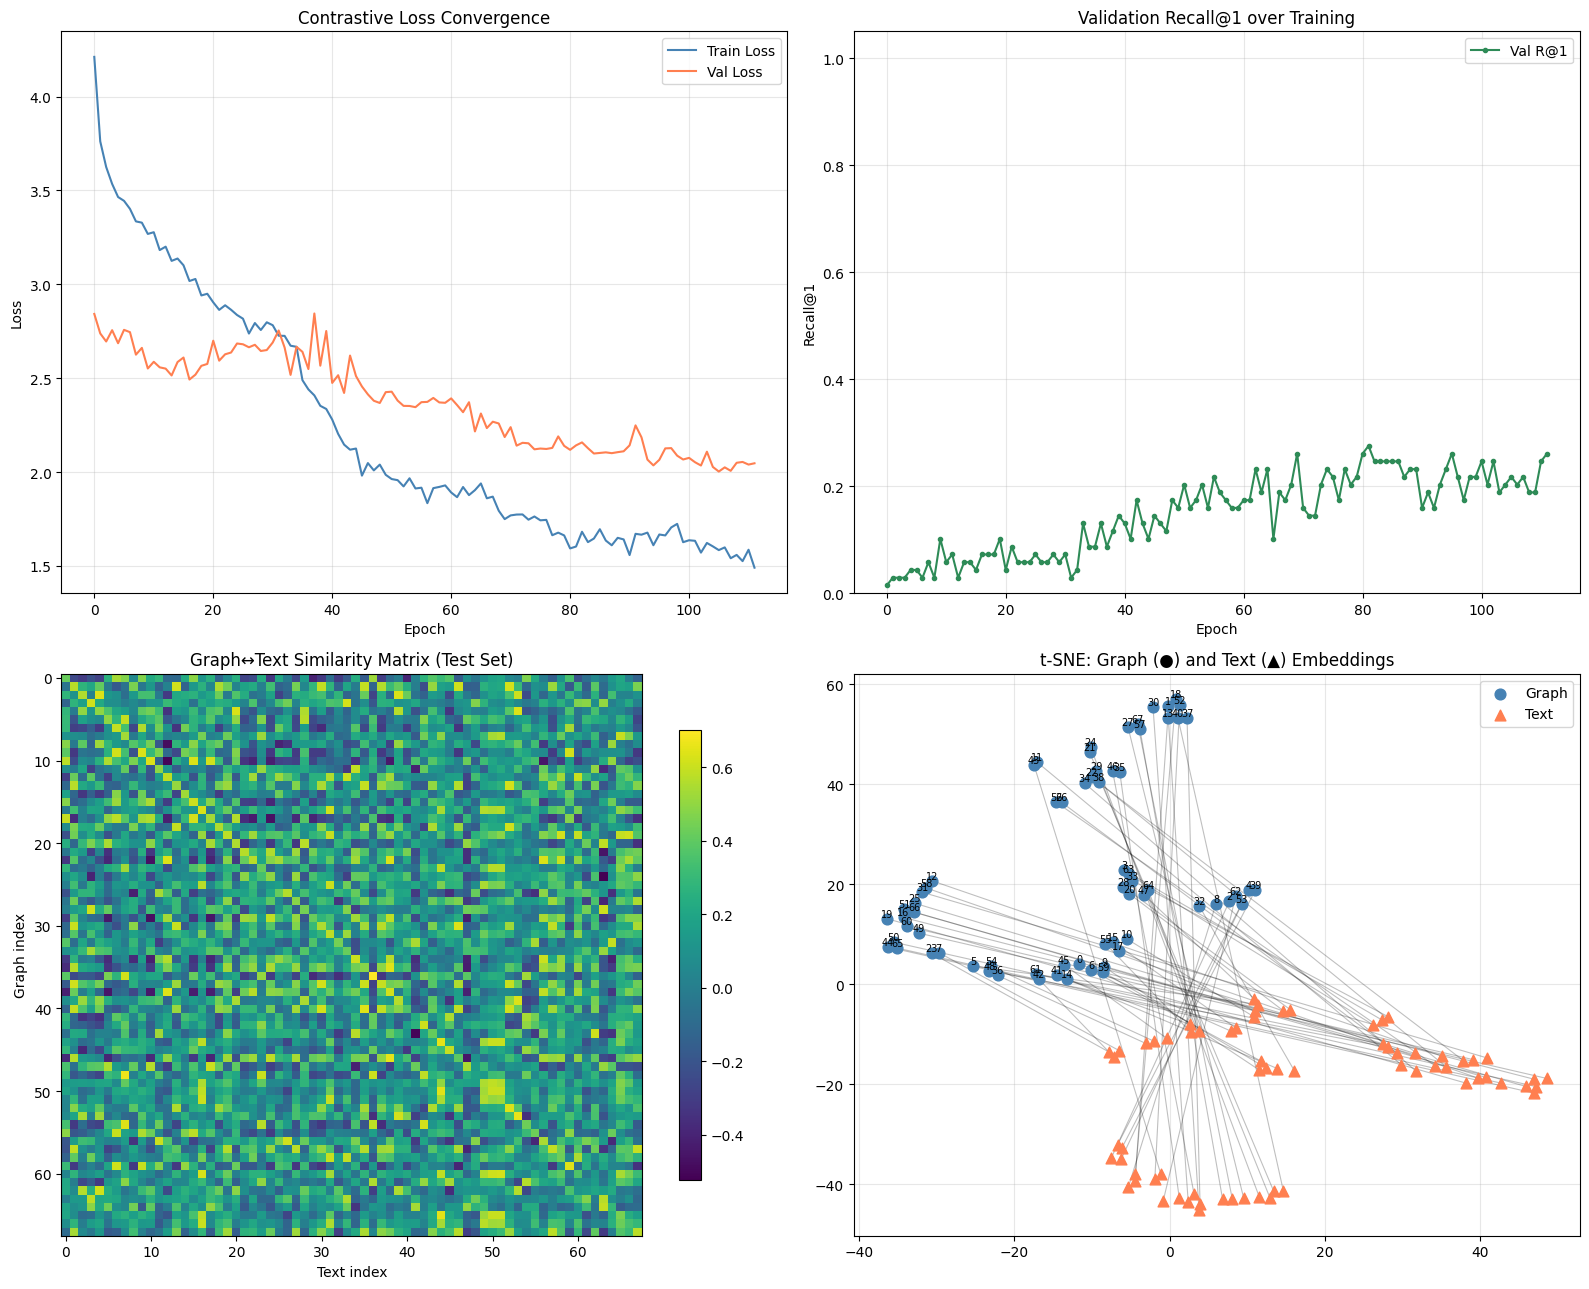

Saved p6_alignment_viz.png


In [26]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

fig, axes = plt.subplots(2, 2, figsize=(16, 13))

# ── 1. Training convergence ──
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='steelblue')
ax.plot(history['val_loss'], label='Val Loss', color='coral')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Contrastive Loss Convergence'); ax.legend(); ax.grid(True, alpha=0.3)

# ── 2. Recall@1 convergence ──
ax = axes[0, 1]
ax.plot(history['val_r1'], label='Val R@1', color='seagreen', marker='o', markersize=3)
ax.set_xlabel('Epoch'); ax.set_ylabel('Recall@1')
ax.set_title('Validation Recall@1 over Training'); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

# ── 3. Test similarity heatmap ──
ax = axes[1,0]
sims = test_metrics['sims'].numpy()
im = ax.imshow(sims, cmap='viridis', aspect='auto')
ax.set_xlabel('Text index'); ax.set_ylabel('Graph index')
ax.set_title('Graph↔Text Similarity Matrix (Test Set)')
fig.colorbar(im, ax=ax, shrink=0.8)

# ── 4. t-SNE of aligned embeddings (test set) ──
ax = axes[1, 1]
zg_np = test_metrics['zg'].numpy()
zt_np = test_metrics['zt'].numpy()
N_test = len(zg_np)
combined = np.concatenate([zg_np, zt_np], axis=0)
perp = min(5, N_test - 1) if N_test > 2 else 1
tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
emb2d = tsne.fit_transform(combined)
g2d, t2d = emb2d[:N_test], emb2d[N_test:]
ax.scatter(g2d[:, 0], g2d[:, 1], c='steelblue', marker='o', s=60, label='Graph', zorder=3)
ax.scatter(t2d[:, 0], t2d[:, 1], c='coral', marker='^', s=60, label='Text', zorder=3)
for i in range(N_test):
    ax.plot([g2d[i, 0], t2d[i, 0]], [g2d[i, 1], t2d[i, 1]],
            'k-', alpha=0.25, linewidth=0.8)
    ax.annotate(str(i), (g2d[i, 0], g2d[i, 1]), fontsize=7, ha='center', va='bottom')
ax.set_title('t-SNE: Graph (●) and Text (▲) Embeddings')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('p6_alignment_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved p6_alignment_viz.png")

In [24]:
# Per-sample analysis: which alignments succeeded vs failed?
sims_test = test_metrics['sims']
N_t = sims_test.size(0)
predicted = sims_test.argmax(dim=1)
correct = (predicted == torch.arange(N_t))

print("=" * 70)
print("ALIGNMENT SUCCESS / FAILURE ANALYSIS (Test Set)")
print("=" * 70)

for i in range(N_t):
    prob_name = test_pairs[i]['prob']
    text_snippet = test_pairs[i]['text'][:100].replace('\n', ' ')
    pred_idx = predicted[i].item()
    diag_score = sims_test[i, i].item()
    pred_score = sims_test[i, pred_idx].item()
    status = "CORRECT" if correct[i] else "WRONG"

    print(f"\n[{status}] Graph {i} ({prob_name})")
    print(f"  Text: \"{text_snippet}...\"")
    print(f"  Diagonal score: {diag_score:.4f} | Predicted: idx={pred_idx} score={pred_score:.4f}")
    if not correct[i]:
        confused_prob = test_pairs[pred_idx]['prob']
        confused_text = test_pairs[pred_idx]['text'][:80].replace('\n', ' ')
        print(f"  Confused with: {confused_prob} — \"{confused_text}...\"")

n_correct = correct.sum().item()
print(f"\nSummary: {n_correct}/{N_t} correct ({100*n_correct/N_t:.1f}%)")

ALIGNMENT SUCCESS / FAILURE ANALYSIS (Test Set)

[WRONG] Graph 0 (NLP4LP/prob_010)
  Text: "A bakery uses a stand-mixer and a slow bake oven to make bread and cookies. Each machine can run for..."
  Diagonal score: 0.4157 | Predicted: idx=6 score=0.5381
  Confused with: NLP4LP/prob_018 — "A candy store mixes regular candy and sour candy to prepare two products, regula..."

[WRONG] Graph 1 (NLP4LP/prob_145)
  Text: "A shoe company supplies shoes to stores via vans and trucks. A van can transport 50 pairs of shoes w..."
  Diagonal score: 0.5711 | Predicted: idx=52 score=0.6203
  Confused with: NLP4LP/prob_043 — "A woodshop can purchase two types of saws, a miter saw and a circular saw. A mit..."

[WRONG] Graph 2 (NLP4LP/prob_150)
  Text: "A toy store decides to deliver gifts using two shipping companies, a new one and an old one. The new..."
  Diagonal score: 0.5581 | Predicted: idx=4 score=0.6381
  Confused with: NLP4LP/prob_110 — "A travelling salesman only eats ramen and fries. Each p

### Written Answers

Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?
2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?
3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?


1. (5 points) Any surprising results from using this on your dataset?

Honestly, I was surprised it worked at all on a dataset of only 92 problems. With a batch size of 8, we only get 7 negatives per positive, which is a super weak signal compared to huge models like CLIP. It was interesting to see the learnable temperature scale grow so quickly during training to sharpen the similarity scores and make up for the small batch size. However, the alignment is pretty fragile. The model easily confuses problems with similar math structures (like two different scheduling problems) because their GCN graph embeddings end up looking almost identical in the shared space.

2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?

Cross-entropy is used because contrastive alignment basically treats matching as a classification problem within the batch. If your batch size is B, the model is trying to pick the 1 correct text out of B possible options for each graph. Cross-entropy works perfectly for this: it uses softmax to maximize the probability of the true pair while simultaneously pushing down the probabilities of all the other in-batch negatives. It's much more efficient than something like triplet loss because you use all the negatives in the batch at once without needing to explicitly mine for hard negatives.

3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

Based on the t-SNE plot and similarity heatmap:

* Where it worked: Successful alignments show up as points where the graph and text embeddings almost completely overlap (or form a strong diagonal on the heatmap). These are usually problems with really distinct mathematical structures (like a unique network flow problem) that stand out from the rest.
* Where it failed: Failures show up as long or crossed lines connecting the pairs. This usually happens when two problems share a very similar MILP graph structure (like two different job scheduling tasks) but have different text descriptions.
* Why it happens: I suspect this is due to the modality gap. The natural language text has a lot of semantic context (like the real-world motivation) that the GCN just can't extract from the raw graph topology, causing it to confuse structurally similar graphs.

# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?
2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?

1. What concept did you find the most interesting?

I found contrastive learning with hard negatives the most interesting. In Problem 6, I realized that naive random negatives let the model cheat using surface-level cues. Generating hard negatives by perturbing the graph structure (flipping ≤/≥, swapping variable types, flipping min/max) forces the model to learn true mathematical alignment, which highlighted how critical negative sample construction is in contrastive learning.

2. Which concepts do you see being useful towards your goal?

Our group project focuses on Language-MILP alignment, so two concepts are directly useful. First, Late Fusion worked best in Problem 5 given the large modality gap between text and MILP graphs, and fits my current needs. Second, the contrastive learning architecture from Problem 6 (Transformer + GCN mapped into a shared space) provides a solid starting paradigm for our work.